In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
import sys, os

from prompt_toolkit.contrib.telnet import TelnetServer

sys.path.append(str(Path(os.getcwd()).parent))
from GrooveModel.Utils.DNAValue import *

from scipy.stats import entropy
from scipy.stats import wasserstein_distance


import seaborn as sns
from seaborn import histplot

import matplotlib as mpl
import matplotlib.pyplot as plt

plt.style.use("default")
mpl.rcParams.update(mpl.rcParamsDefault)


# Load Data

In [4]:
eval_data = pd.read_csv('eval_metadata_old.csv')
print(eval_data.shape)
print(eval_data.columns)
eval_data.head()

(37800, 13)
Index(['input_dna', 'input_midi', 'variation', 'model', 'model_type',
       'pretrain_type', 'temperature', 'top_p', 'max_tokens', 'eval_type',
       'unit_count', 'dna', 'midi'],
      dtype='object')


,input_dna,input_midi,variation,model,model_type,pretrain_type,temperature,top_p,max_tokens,eval_type,unit_count,dna,midi
0,EvalData/OriginalInputs/dna/fbo_10_10.json,EvalData/OriginalInputs/midi/fbo_10_10.mid,0,multitask_relgu_finetune,multitask,finetune,0.8,0.8,200,creativeness,144,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/multitask_relgu_finetune_temp0.8_top_...
1,EvalData/OriginalInputs/dna/fbo_10_10.json,EvalData/OriginalInputs/midi/fbo_10_10.mid,1,multitask_relgu_finetune,multitask,finetune,0.8,0.8,200,creativeness,144,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/multitask_relgu_finetune_temp0.8_top_...
2,EvalData/OriginalInputs/dna/fbo_10_10.json,EvalData/OriginalInputs/midi/fbo_10_10.mid,2,multitask_relgu_finetune,multitask,finetune,0.8,0.8,200,creativeness,160,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/multitask_relgu_finetune_temp0.8_top_...
3,EvalData/OriginalInputs/dna/fbo_10_16.json,EvalData/OriginalInputs/midi/fbo_10_16.mid,0,multitask_relgu_finetune,multitask,finetune,0.8,0.8,200,creativeness,128,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/multitask_relgu_finetune_temp0.8_top_...
4,EvalData/OriginalInputs/dna/fbo_10_16.json,EvalData/OriginalInputs/midi/fbo_10_16.mid,1,multitask_relgu_finetune,multitask,finetune,0.8,0.8,200,creativeness,128,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/multitask_relgu_finetune_temp0.8_top_...


In [5]:
eval_data = eval_data[(eval_data['model_type'] == 'multitask') | (eval_data['model'].str.contains('large'))].reset_index(drop=True)

In [6]:
eval_data

,input_dna,input_midi,variation,model,model_type,pretrain_type,temperature,top_p,max_tokens,eval_type,unit_count,dna,midi
0,EvalData/OriginalInputs/dna/fbo_10_10.json,EvalData/OriginalInputs/midi/fbo_10_10.mid,0,multitask_relgu_finetune,multitask,finetune,0.8,0.8,200,creativeness,144,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/multitask_relgu_finetune_temp0.8_top_...
1,EvalData/OriginalInputs/dna/fbo_10_10.json,EvalData/OriginalInputs/midi/fbo_10_10.mid,1,multitask_relgu_finetune,multitask,finetune,0.8,0.8,200,creativeness,144,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/multitask_relgu_finetune_temp0.8_top_...
2,EvalData/OriginalInputs/dna/fbo_10_10.json,EvalData/OriginalInputs/midi/fbo_10_10.mid,2,multitask_relgu_finetune,multitask,finetune,0.8,0.8,200,creativeness,160,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/multitask_relgu_finetune_temp0.8_top_...
3,EvalData/OriginalInputs/dna/fbo_10_16.json,EvalData/OriginalInputs/midi/fbo_10_16.mid,0,multitask_relgu_finetune,multitask,finetune,0.8,0.8,200,creativeness,128,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/multitask_relgu_finetune_temp0.8_top_...
4,EvalData/OriginalInputs/dna/fbo_10_16.json,EvalData/OriginalInputs/midi/fbo_10_16.mid,1,multitask_relgu_finetune,multitask,finetune,0.8,0.8,200,creativeness,128,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/multitask_relgu_finetune_temp0.8_top_...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
25195,EvalData/OriginalInputs/dna/wb_724.json,EvalData/OriginalInputs/midi/wb_724.mid,1,sequential_large_finetune,sequential,finetune,1.0,0.9,400,sequence_length,67,EvalData/sequential_large_finetune_maxtok400/d...,EvalData/sequential_large_finetune_maxtok400/m...
25196,EvalData/OriginalInputs/dna/wb_724.json,EvalData/OriginalInputs/midi/wb_724.mid,2,sequential_large_finetune,sequential,finetune,1.0,0.9,400,sequence_length,67,EvalData/sequential_large_finetune_maxtok400/d...,EvalData/sequential_large_finetune_maxtok400/m...
25197,EvalData/OriginalInputs/dna/wb_834.json,EvalData/OriginalInputs/midi/wb_834.mid,0,sequential_large_finetune,sequential,finetune,1.0,0.9,400,sequence_length,4,EvalData/sequential_large_finetune_maxtok400/d...,EvalData/sequential_large_finetune_maxtok400/m...
25198,EvalData/OriginalInputs/dna/wb_834.json,EvalData/OriginalInputs/midi/wb_834.mid,1,sequential_large_finetune,sequential,finetune,1.0,0.9,400,sequence_length,4,EvalData/sequential_large_finetune_maxtok400/d...,EvalData/sequential_large_finetune_maxtok400/m...


In [7]:
low_count = eval_data[eval_data['unit_count'] < 10].shape[0]
print(f'Number of entries with unit count < 10: {low_count}')

Number of entries with unit count < 10: 4901


In [8]:
# Filter out entries with very low unit counts
eval_data = eval_data[eval_data['unit_count'] >= 10].reset_index(drop=True)
print(f'Filtered eval data shape: {eval_data.shape}')

Filtered eval data shape: (20299, 13)


In [9]:
sequential_outputs = eval_data[eval_data['model_type'] == 'sequential']
sequential_outputs.head()

,input_dna,input_midi,variation,model,model_type,pretrain_type,temperature,top_p,max_tokens,eval_type,unit_count,dna,midi
12600,EvalData/OriginalInputs/dna/fbo_10_10.json,EvalData/OriginalInputs/midi/fbo_10_10.mid,0,sequential_large,sequential,pretrain,0.8,0.8,200,creativeness,53,EvalData/sequential_large_temp0.8_top_p0.8/dna...,EvalData/sequential_large_temp0.8_top_p0.8/mid...
12601,EvalData/OriginalInputs/dna/fbo_10_10.json,EvalData/OriginalInputs/midi/fbo_10_10.mid,1,sequential_large,sequential,pretrain,0.8,0.8,200,creativeness,57,EvalData/sequential_large_temp0.8_top_p0.8/dna...,EvalData/sequential_large_temp0.8_top_p0.8/mid...
12602,EvalData/OriginalInputs/dna/fbo_10_10.json,EvalData/OriginalInputs/midi/fbo_10_10.mid,2,sequential_large,sequential,pretrain,0.8,0.8,200,creativeness,54,EvalData/sequential_large_temp0.8_top_p0.8/dna...,EvalData/sequential_large_temp0.8_top_p0.8/mid...
12603,EvalData/OriginalInputs/dna/fbo_10_16.json,EvalData/OriginalInputs/midi/fbo_10_16.mid,0,sequential_large,sequential,pretrain,0.8,0.8,200,creativeness,43,EvalData/sequential_large_temp0.8_top_p0.8/dna...,EvalData/sequential_large_temp0.8_top_p0.8/mid...
12604,EvalData/OriginalInputs/dna/fbo_10_16.json,EvalData/OriginalInputs/midi/fbo_10_16.mid,1,sequential_large,sequential,pretrain,0.8,0.8,200,creativeness,39,EvalData/sequential_large_temp0.8_top_p0.8/dna...,EvalData/sequential_large_temp0.8_top_p0.8/mid...


In [10]:
multi_outputs = eval_data[eval_data['model_type'] == 'multitask']
multi_outputs.head()

,input_dna,input_midi,variation,model,model_type,pretrain_type,temperature,top_p,max_tokens,eval_type,unit_count,dna,midi
0,EvalData/OriginalInputs/dna/fbo_10_10.json,EvalData/OriginalInputs/midi/fbo_10_10.mid,0,multitask_relgu_finetune,multitask,finetune,0.8,0.8,200,creativeness,144,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/multitask_relgu_finetune_temp0.8_top_...
1,EvalData/OriginalInputs/dna/fbo_10_10.json,EvalData/OriginalInputs/midi/fbo_10_10.mid,1,multitask_relgu_finetune,multitask,finetune,0.8,0.8,200,creativeness,144,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/multitask_relgu_finetune_temp0.8_top_...
2,EvalData/OriginalInputs/dna/fbo_10_10.json,EvalData/OriginalInputs/midi/fbo_10_10.mid,2,multitask_relgu_finetune,multitask,finetune,0.8,0.8,200,creativeness,160,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/multitask_relgu_finetune_temp0.8_top_...
3,EvalData/OriginalInputs/dna/fbo_10_16.json,EvalData/OriginalInputs/midi/fbo_10_16.mid,0,multitask_relgu_finetune,multitask,finetune,0.8,0.8,200,creativeness,128,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/multitask_relgu_finetune_temp0.8_top_...
4,EvalData/OriginalInputs/dna/fbo_10_16.json,EvalData/OriginalInputs/midi/fbo_10_16.mid,1,multitask_relgu_finetune,multitask,finetune,0.8,0.8,200,creativeness,128,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/multitask_relgu_finetune_temp0.8_top_...


# Comparison Metrics

## Sanity checks

In [11]:
def compute_nomml(onsets, tpqn, k=6):
    """
    Compute the Note Onset Median Metric Level (NOMML) heuristic.
    onsets: list of onset ticks (ints)
    tpqn: ticks per quarter note
    k: depth of metric level hierarchy (default=6)
    """
    levels = []

    for o in onsets:
        found = False

        # --- Duple levels (even numbers)
        for j in range(k):
            p = tpqn / (2 ** j)
            if o % p == 0:
                levels.append(2 * j)
                found = True
                break

        # --- Triplet levels (odd numbers)
        if not found:
            for j in range(k):
                p = (2 * tpqn) / (3 * (2 ** j))
                if o % p == 0:
                    levels.append(2 * j + 1)
                    found = True
                    break

        # --- Beyond both grids
        if not found:
            levels.append(2 * k)

    return np.median(levels) if levels else np.nan

In [12]:
# NOMML, DNODR, DNVR, ...
# to sanity check if output is expressive

if Path('giga_eval_results.csv').exists():
    giga_eval_results = pd.read_csv('giga_eval_results.csv')
else:
    results = []

    for dna in eval_data['dna']:
        unique_velocities = set()
        unique_offsets = set()

        with open(dna, 'r') as f:
            out_dna = json.load(f)[0]

            for dna_unit in out_dna.get('DNAUnits', []):
                vel_dict = dna_unit.get('VelocityPerValuePart', {})
                off_dict = dna_unit.get('OffsetTicksPerValuePart', {})

                # Rest case
                if not vel_dict:
                    unique_velocities.add(0)
                    continue
                if not off_dict:
                    unique_offsets.add(0)
                    continue

                # Process velocities
                for v in vel_dict.values():
                    # Convert normalized float back to integer MIDI velocity
                    midi_velocity = int(round(v * 128))
                    # Clamp to valid range [0, 127]
                    midi_velocity = max(0, min(127, midi_velocity))
                    unique_velocities.add(midi_velocity)

                # Process offsets
                for o in off_dict.values():
                    unique_offsets.add(o)

                # nomml
                tpqn = out_dna.get('TicksPerQuarterNote', 480)

                onsets = []
                for dna_unit in out_dna.get('DNAUnits', []):
                    off_dict = dna_unit.get('OffsetTicksPerValuePart', {})
                    for o in off_dict.values():
                        onsets.append(o)

                nomml = compute_nomml(onsets, tpqn)

        results.append({
            'dna_file': dna,
            'unique_velocity_count': len(unique_velocities),
            'dnvr': len(unique_velocities) / 128.0,
            'unique_offset_count': len(unique_offsets),
            'dnodr': len(unique_offsets) / out_dna.get('TicksPerGridUnit', 120),
            'nomml': nomml
        })

    giga_eval_results = pd.DataFrame(results)
    giga_eval_results.to_csv('giga_eval_results.csv', index=False)

In [13]:
giga_eval_results

,dna_file,unique_velocity_count,dnvr,unique_offset_count,dnodr,nomml
0,EvalData/multitask_relgu_finetune_temp0.8_top_...,23,0.179688,4,0.033333,12.0
1,EvalData/multitask_relgu_finetune_temp0.8_top_...,33,0.257812,4,0.033333,12.0
2,EvalData/multitask_relgu_finetune_temp0.8_top_...,33,0.257812,3,0.025000,12.0
3,EvalData/multitask_relgu_finetune_temp0.8_top_...,13,0.101562,3,0.025000,12.0
4,EvalData/multitask_relgu_finetune_temp0.8_top_...,14,0.109375,3,0.025000,12.0
...,...,...,...,...,...,...
20294,EvalData/sequential_large_finetune_maxtok400/d...,12,0.093750,6,0.050000,12.0
20295,EvalData/sequential_large_finetune_maxtok400/d...,20,0.156250,10,0.083333,12.0
20296,EvalData/sequential_large_finetune_maxtok400/d...,7,0.054688,6,0.050000,12.0
20297,EvalData/sequential_large_finetune_maxtok400/d...,10,0.078125,7,0.058333,12.0


In [14]:
giga_eval_results['nomml'].count()

np.int64(20299)

## Statistical Parameters of Output (mean, std,...)

In [15]:
stats_results = []

if Path('eval_stats.csv').exists():
    stats_results = pd.read_csv('eval_stats.csv').to_dict(orient='records')
else:
    for dna, input_dna in zip(eval_data['dna'], eval_data['input_dna']):
        def get_stats_from_dna(path):
            with open(path, 'r') as f:
                data = json.load(f)[0]

            all_velocities = []
            all_offsets = []

            for dna_unit in data.get('DNAUnits', []):
                vel_dict = dna_unit.get('VelocityPerValuePart', {})
                off_dict = dna_unit.get('OffsetTicksPerValuePart', {})

                # velocities (normalize → MIDI range)
                for v in vel_dict.values():
                    midi_velocity = int(round(v * 128))
                    midi_velocity = max(0, min(127, midi_velocity))
                    all_velocities.append(midi_velocity)

                # offsets (tick units)
                for o in off_dict.values():
                    all_offsets.append(o)

            # handle empty cases
            if len(all_velocities) == 0:
                all_velocities = [0]
            if len(all_offsets) == 0:
                all_offsets = [0]

            return {
                'vel_mean': np.mean(all_velocities),
                'vel_std': np.std(all_velocities),
                'vel_min': np.min(all_velocities),
                'vel_max': np.max(all_velocities),
                'vel_median': np.median(all_velocities),
                'vel_range': np.ptp(all_velocities),
                'off_mean': np.mean(all_offsets),
                'off_std': np.std(all_offsets),
                'off_min': np.min(all_offsets),
                'off_max': np.max(all_offsets),
                'off_median': np.median(all_offsets),
                'off_range': np.ptp(all_offsets),
            }

        # --- Get stats for both target and input DNA ---
        eval_stats = get_stats_from_dna(dna)
        input_stats = get_stats_from_dna(input_dna)

        # --- Combine into one record ---
        stats_results.append({
            'dna_file': dna,
            'input_dna_file': input_dna,
            **{k: v for k, v in eval_stats.items()},
            **{f'input_{k}': v for k, v in input_stats.items()},
        })

    stats_df = pd.DataFrame(stats_results)
    stats_df.to_csv('eval_stats.csv', index=False)

In [16]:
# compare mean std
stats_df = pd.DataFrame(stats_results)
stats_df

,dna_file,input_dna_file,vel_mean,vel_std,vel_min,vel_max,vel_median,vel_range,off_mean,off_std,...,input_vel_min,input_vel_max,input_vel_median,input_vel_range,input_off_mean,input_off_std,input_off_min,input_off_max,input_off_median,input_off_range
0,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/OriginalInputs/dna/fbo_10_10.json,99.138462,38.365801,0,127,126.0,127,1.407692,0.664439,...,26,127,127.0,101,3.382775,7.434363,-33,42,3.0,75
1,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/OriginalInputs/dna/fbo_10_10.json,103.020134,30.548777,33,127,124.0,94,1.281879,0.613938,...,26,127,127.0,101,3.382775,7.434363,-33,42,3.0,75
2,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/OriginalInputs/dna/fbo_10_10.json,101.098160,39.322360,14,127,124.0,113,1.116564,0.420234,...,26,127,127.0,101,3.382775,7.434363,-33,42,3.0,75
3,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/OriginalInputs/dna/fbo_10_16.json,119.827225,12.668405,85,127,124.0,42,1.188482,0.453114,...,33,127,127.0,94,2.971831,3.445642,-9,9,3.0,18
4,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/OriginalInputs/dna/fbo_10_16.json,120.380208,11.482606,85,127,124.0,42,1.156250,0.390729,...,33,127,127.0,94,2.971831,3.445642,-9,9,3.0,18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20294,EvalData/sequential_large_finetune_maxtok400/d...,EvalData/OriginalInputs/dna/wb_6939.json,116.282051,21.461891,45,127,127.0,82,-2.307692,3.360051,...,37,127,127.0,90,4.435897,3.447741,-9,12,5.0,21
20295,EvalData/sequential_large_finetune_maxtok400/d...,EvalData/OriginalInputs/dna/wb_6967.json,112.820513,24.139946,45,127,127.0,82,2.423077,6.039441,...,55,127,127.0,72,2.957746,4.845316,-7,30,3.0,37
20296,EvalData/sequential_large_finetune_maxtok400/d...,EvalData/OriginalInputs/dna/wb_724.json,125.025641,8.078103,77,127,127.0,50,6.846154,3.254492,...,112,127,127.0,15,6.583333,6.812468,-11,26,7.0,37
20297,EvalData/sequential_large_finetune_maxtok400/d...,EvalData/OriginalInputs/dna/wb_724.json,125.136364,4.515584,98,127,127.0,29,6.784091,3.575322,...,112,127,127.0,15,6.583333,6.812468,-11,26,7.0,37


In [17]:
stats_df.columns

Index(['dna_file', 'input_dna_file', 'vel_mean', 'vel_std', 'vel_min',
       'vel_max', 'vel_median', 'vel_range', 'off_mean', 'off_std', 'off_min',
       'off_max', 'off_median', 'off_range', 'input_vel_mean', 'input_vel_std',
       'input_vel_min', 'input_vel_max', 'input_vel_median', 'input_vel_range',
       'input_off_mean', 'input_off_std', 'input_off_min', 'input_off_max',
       'input_off_median', 'input_off_range'],
      dtype='object')

In [18]:
#
multi_stats = stats_df.merge(
    multi_outputs,
    left_on="dna_file",
    right_on="dna",
    how="inner",
    validate="one_to_one"
)

multi_stats.head()

,dna_file,input_dna_file,vel_mean,vel_std,vel_min,vel_max,vel_median,vel_range,off_mean,off_std,...,model,model_type,pretrain_type,temperature,top_p,max_tokens,eval_type,unit_count,dna,midi
0,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/OriginalInputs/dna/fbo_10_10.json,99.138462,38.365801,0,127,126.0,127,1.407692,0.664439,...,multitask_relgu_finetune,multitask,finetune,0.8,0.8,200,creativeness,144,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/multitask_relgu_finetune_temp0.8_top_...
1,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/OriginalInputs/dna/fbo_10_10.json,103.020134,30.548777,33,127,124.0,94,1.281879,0.613938,...,multitask_relgu_finetune,multitask,finetune,0.8,0.8,200,creativeness,144,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/multitask_relgu_finetune_temp0.8_top_...
2,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/OriginalInputs/dna/fbo_10_10.json,101.098160,39.322360,14,127,124.0,113,1.116564,0.420234,...,multitask_relgu_finetune,multitask,finetune,0.8,0.8,200,creativeness,160,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/multitask_relgu_finetune_temp0.8_top_...
3,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/OriginalInputs/dna/fbo_10_16.json,119.827225,12.668405,85,127,124.0,42,1.188482,0.453114,...,multitask_relgu_finetune,multitask,finetune,0.8,0.8,200,creativeness,128,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/multitask_relgu_finetune_temp0.8_top_...
4,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/OriginalInputs/dna/fbo_10_16.json,120.380208,11.482606,85,127,124.0,42,1.156250,0.390729,...,multitask_relgu_finetune,multitask,finetune,0.8,0.8,200,creativeness,128,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/multitask_relgu_finetune_temp0.8_top_...


In [19]:
seq_stats = stats_df.merge(
    sequential_outputs,
    left_on="dna_file",
    right_on="dna",
    how="inner",
    validate="one_to_one"
)
seq_stats.head()

,dna_file,input_dna_file,vel_mean,vel_std,vel_min,vel_max,vel_median,vel_range,off_mean,off_std,...,model,model_type,pretrain_type,temperature,top_p,max_tokens,eval_type,unit_count,dna,midi
0,EvalData/sequential_large_temp0.8_top_p0.8/dna...,EvalData/OriginalInputs/dna/fbo_10_10.json,111.583333,30.102487,49,127,127.0,78,1.250000,3.614208,...,sequential_large,sequential,pretrain,0.8,0.8,200,creativeness,53,EvalData/sequential_large_temp0.8_top_p0.8/dna...,EvalData/sequential_large_temp0.8_top_p0.8/mid...
1,EvalData/sequential_large_temp0.8_top_p0.8/dna...,EvalData/OriginalInputs/dna/fbo_10_10.json,105.425532,33.175064,47,127,127.0,80,2.170213,2.529142,...,sequential_large,sequential,pretrain,0.8,0.8,200,creativeness,57,EvalData/sequential_large_temp0.8_top_p0.8/dna...,EvalData/sequential_large_temp0.8_top_p0.8/mid...
2,EvalData/sequential_large_temp0.8_top_p0.8/dna...,EvalData/OriginalInputs/dna/fbo_10_10.json,107.333333,32.381408,45,127,127.0,82,3.187500,4.171612,...,sequential_large,sequential,pretrain,0.8,0.8,200,creativeness,54,EvalData/sequential_large_temp0.8_top_p0.8/dna...,EvalData/sequential_large_temp0.8_top_p0.8/mid...
3,EvalData/sequential_large_temp0.8_top_p0.8/dna...,EvalData/OriginalInputs/dna/fbo_10_16.json,114.269231,24.704496,59,127,127.0,68,-0.692308,2.089704,...,sequential_large,sequential,pretrain,0.8,0.8,200,creativeness,43,EvalData/sequential_large_temp0.8_top_p0.8/dna...,EvalData/sequential_large_temp0.8_top_p0.8/mid...
4,EvalData/sequential_large_temp0.8_top_p0.8/dna...,EvalData/OriginalInputs/dna/fbo_10_16.json,116.962264,22.232020,63,127,127.0,64,-0.396226,2.021951,...,sequential_large,sequential,pretrain,0.8,0.8,200,creativeness,39,EvalData/sequential_large_temp0.8_top_p0.8/dna...,EvalData/sequential_large_temp0.8_top_p0.8/mid...


C:\Users\minem\AppData\Local\Temp\ipykernel_30996\1239343324.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=['Input', 'Multitask Predictions', 'Sequential Predictions'])


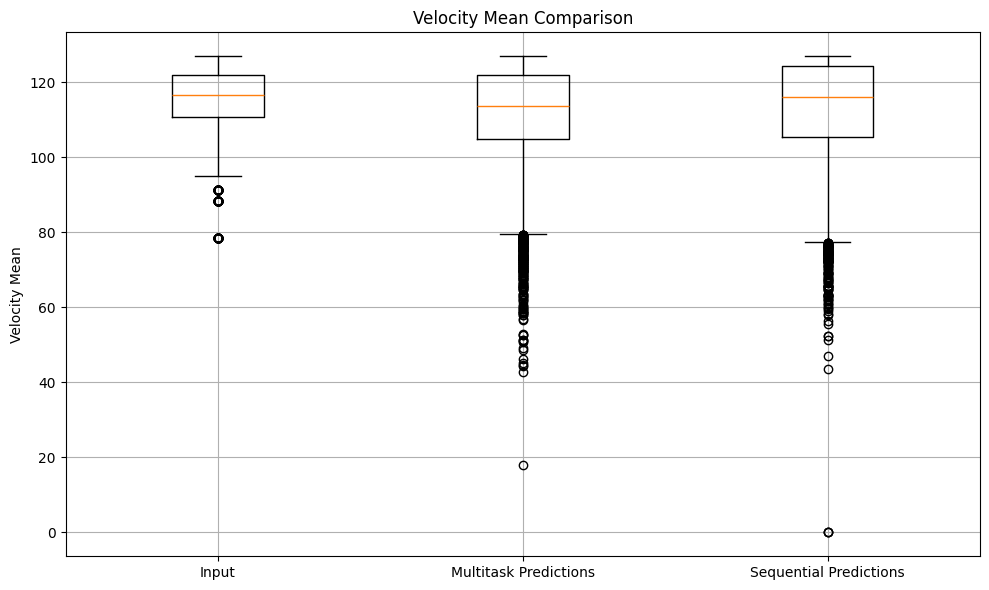

In [20]:
# boxplots of velocity means
plt.figure(figsize=(10, 6))
data_to_plot = [
    multi_stats['input_vel_mean'],
    multi_stats['vel_mean'],
    seq_stats['vel_mean'],
]
plt.boxplot(data_to_plot, labels=['Input', 'Multitask Predictions', 'Sequential Predictions'])
plt.title('Velocity Mean Comparison')
plt.ylabel('Velocity Mean')
plt.grid()
plt.tight_layout()
plt.show()

C:\Users\minem\AppData\Local\Temp\ipykernel_30996\797922975.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=['Input', 'Multitask Predictions', 'Sequential Predictions'])


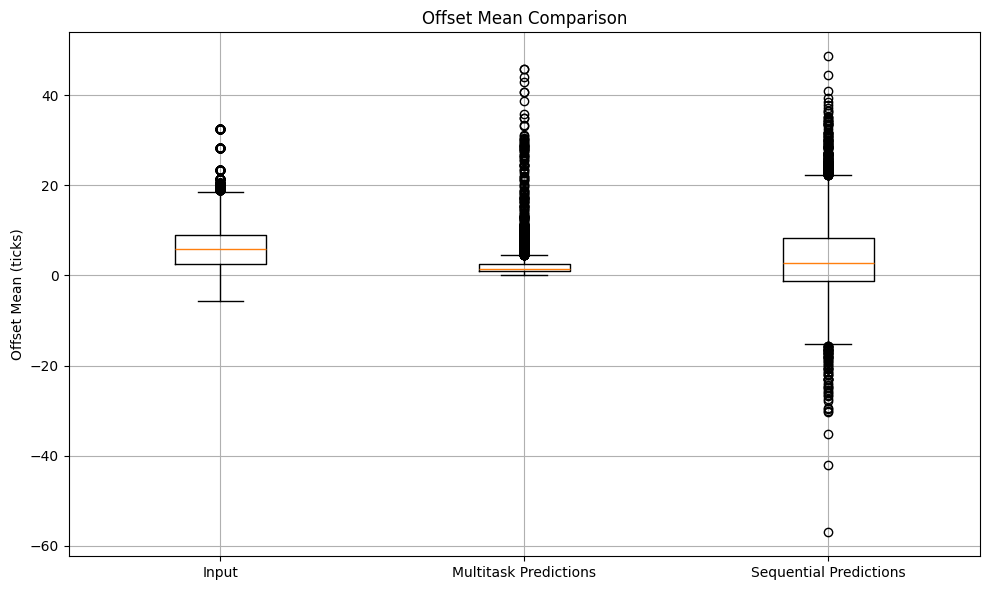

In [21]:
# boxplots of offset means
plt.figure(figsize=(10, 6))
data_to_plot = [
    multi_stats['input_off_mean'],
    multi_stats['off_mean'],
    seq_stats['off_mean'],
]
plt.boxplot(data_to_plot, labels=['Input', 'Multitask Predictions', 'Sequential Predictions'])
plt.title('Offset Mean Comparison')
plt.ylabel('Offset Mean (ticks)')
plt.grid()
plt.tight_layout()
plt.show()

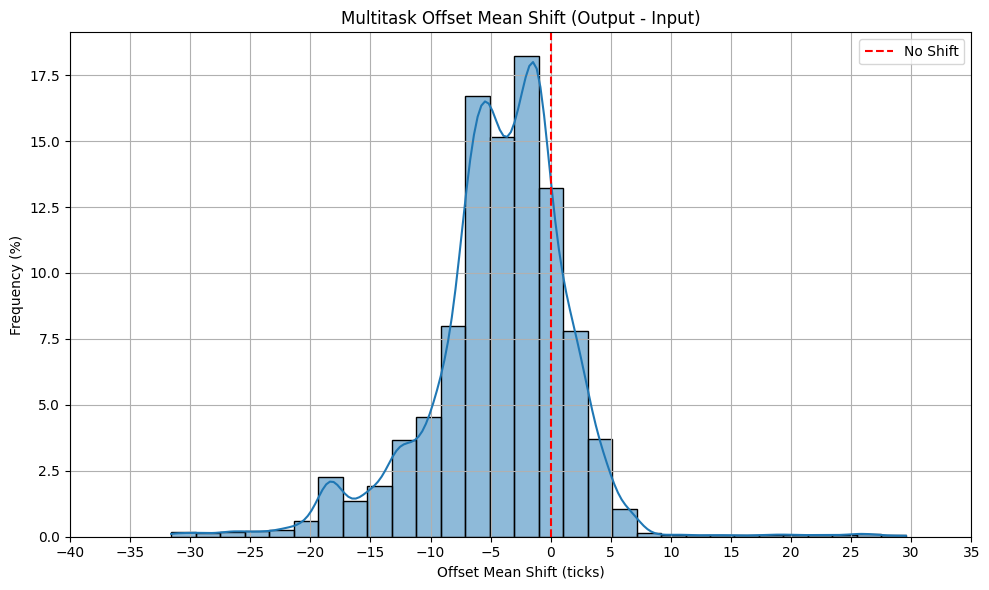

In [22]:
off_diff = multi_stats['off_mean'] - multi_stats['input_off_mean']
off_diff = off_diff[(off_diff >= -40) & (off_diff <= 40)]

plt.figure(figsize=(10, 6))
sns.histplot(off_diff, bins=30, kde=True, stat='percent')
plt.title('Multitask Offset Mean Shift (Output - Input)')
plt.xlabel('Offset Mean Shift (ticks)')
plt.xticks(range(-40, 40, 5))
plt.ylabel('Frequency (%)')
plt.axvline(0, color='red', linestyle='--', label='No Shift')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

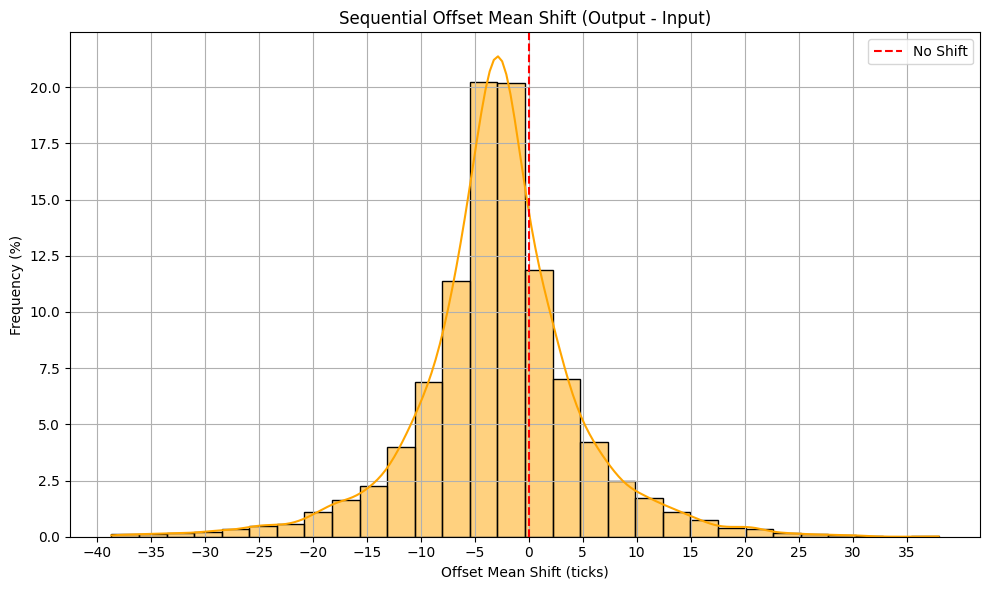

In [23]:
off_diff = seq_stats['off_mean'] - seq_stats['input_off_mean']
off_diff = off_diff[(off_diff >= -40) & (off_diff <= 40)]


plt.figure(figsize=(10, 6))
sns.histplot(off_diff, bins=30, kde=True, stat='percent', color='orange')
plt.title('Sequential Offset Mean Shift (Output - Input)')
plt.xlabel('Offset Mean Shift (ticks)')
plt.xticks(range(-40, 40, 5))
plt.ylabel('Frequency (%)')
plt.axvline(0, color='red', linestyle='--', label='No Shift')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

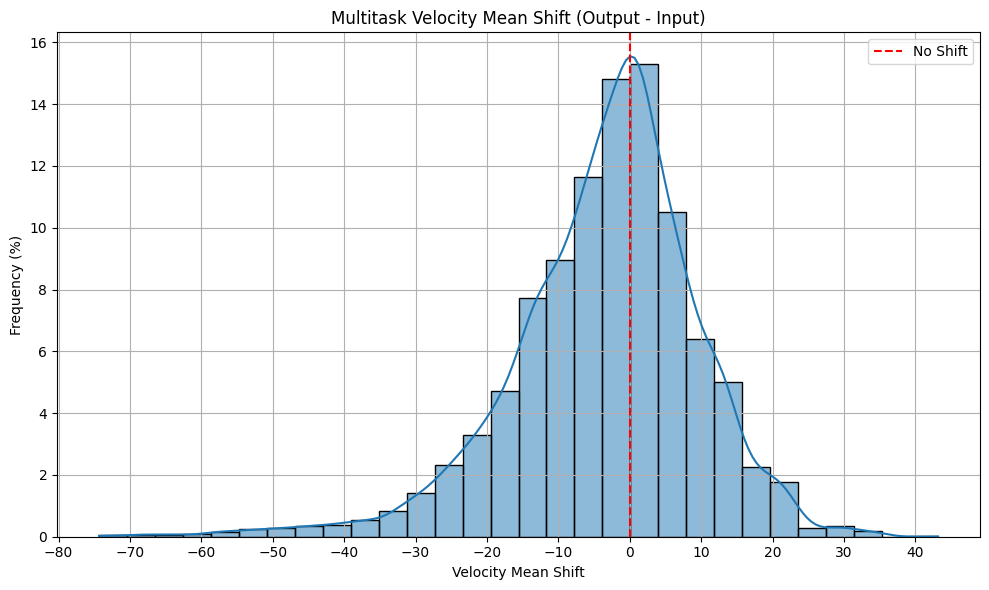

In [24]:
vel_diff = multi_stats['vel_mean'] - multi_stats['input_vel_mean']
vel_diff = vel_diff[vel_diff >= -80]

plt.figure(figsize=(10, 6))
sns.histplot(vel_diff, bins=30, kde=True, stat='percent')
plt.title('Multitask Velocity Mean Shift (Output - Input)')
plt.xlabel('Velocity Mean Shift')
plt.xticks(range(-80, 50, 10))
plt.ylabel('Frequency (%)')
plt.axvline(0, color='red', linestyle='--', label='No Shift')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

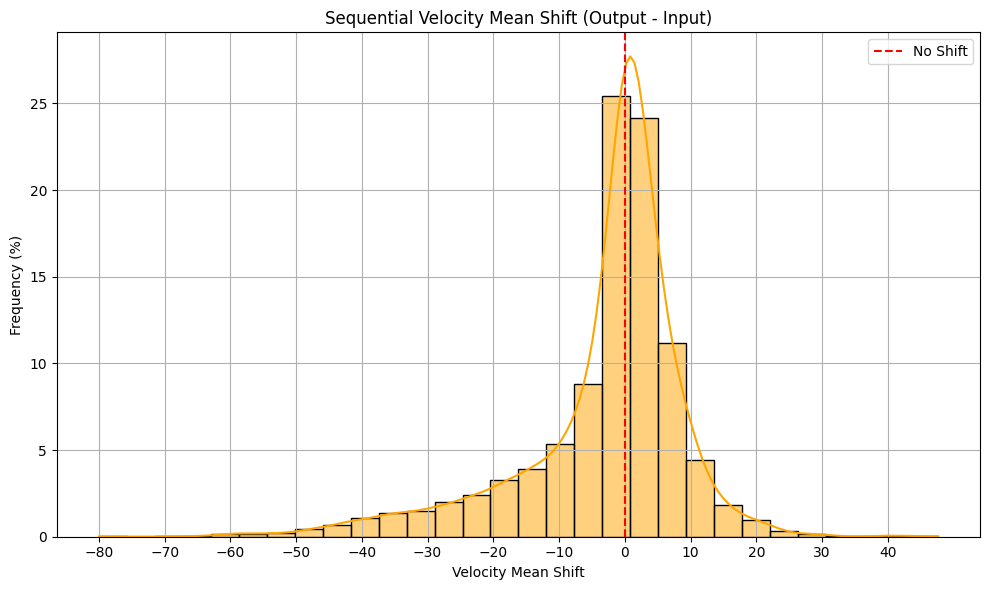

In [25]:
vel_diff = seq_stats['vel_mean'] - seq_stats['input_vel_mean']
vel_diff = vel_diff[vel_diff >= -80]

plt.figure(figsize=(10, 6))
sns.histplot(vel_diff, bins=30, kde=True, stat='percent', color='orange')
plt.title('Sequential Velocity Mean Shift (Output - Input)')
plt.xlabel('Velocity Mean Shift')
plt.xticks(range(-80, 50, 10))
plt.ylabel('Frequency (%)')
plt.axvline(0, color='red', linestyle='--', label='No Shift')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [26]:
# correlations ->
vel_corr = stats_df[['vel_mean', 'input_vel_mean']].corr().iloc[0, 1]
off_corr = stats_df[['off_mean', 'input_off_mean']].corr().iloc[0, 1]
print(f'Velocity Mean Correlation: {vel_corr:.4f}')
print(f'Offset Mean Correlation: {off_corr:.4f}')

Velocity Mean Correlation: 0.2783
Offset Mean Correlation: 0.3080


In [27]:
# table of total mean and std for velocity and offset over sequential and multitask
seq_stats.head()

,dna_file,input_dna_file,vel_mean,vel_std,vel_min,vel_max,vel_median,vel_range,off_mean,off_std,...,model,model_type,pretrain_type,temperature,top_p,max_tokens,eval_type,unit_count,dna,midi
0,EvalData/sequential_large_temp0.8_top_p0.8/dna...,EvalData/OriginalInputs/dna/fbo_10_10.json,111.583333,30.102487,49,127,127.0,78,1.250000,3.614208,...,sequential_large,sequential,pretrain,0.8,0.8,200,creativeness,53,EvalData/sequential_large_temp0.8_top_p0.8/dna...,EvalData/sequential_large_temp0.8_top_p0.8/mid...
1,EvalData/sequential_large_temp0.8_top_p0.8/dna...,EvalData/OriginalInputs/dna/fbo_10_10.json,105.425532,33.175064,47,127,127.0,80,2.170213,2.529142,...,sequential_large,sequential,pretrain,0.8,0.8,200,creativeness,57,EvalData/sequential_large_temp0.8_top_p0.8/dna...,EvalData/sequential_large_temp0.8_top_p0.8/mid...
2,EvalData/sequential_large_temp0.8_top_p0.8/dna...,EvalData/OriginalInputs/dna/fbo_10_10.json,107.333333,32.381408,45,127,127.0,82,3.187500,4.171612,...,sequential_large,sequential,pretrain,0.8,0.8,200,creativeness,54,EvalData/sequential_large_temp0.8_top_p0.8/dna...,EvalData/sequential_large_temp0.8_top_p0.8/mid...
3,EvalData/sequential_large_temp0.8_top_p0.8/dna...,EvalData/OriginalInputs/dna/fbo_10_16.json,114.269231,24.704496,59,127,127.0,68,-0.692308,2.089704,...,sequential_large,sequential,pretrain,0.8,0.8,200,creativeness,43,EvalData/sequential_large_temp0.8_top_p0.8/dna...,EvalData/sequential_large_temp0.8_top_p0.8/mid...
4,EvalData/sequential_large_temp0.8_top_p0.8/dna...,EvalData/OriginalInputs/dna/fbo_10_16.json,116.962264,22.232020,63,127,127.0,64,-0.396226,2.021951,...,sequential_large,sequential,pretrain,0.8,0.8,200,creativeness,39,EvalData/sequential_large_temp0.8_top_p0.8/dna...,EvalData/sequential_large_temp0.8_top_p0.8/mid...


## Kullback Leibler Divergence/ Earth Movers Distance (Wasserstein)/ Mutual Information Score

In [28]:
# compare human vs predicted distributions

dist_results = []

if Path('eval_distances.csv').exists():
    dist_results = pd.read_csv('eval_distances.csv').to_dict(orient='records')
else:
    def get_distributions_from_dna(path):
        with open(path, 'r') as f:
            data = json.load(f)[0]

        all_velocities = []
        all_offsets = []

        for dna_unit in data.get('DNAUnits', []):
            vel_dict = dna_unit.get('VelocityPerValuePart', {})
            off_dict = dna_unit.get('OffsetTicksPerValuePart', {})

            # velocities (normalize → MIDI range)
            for v in vel_dict.values():
                midi_velocity = int(round(v * 128))
                midi_velocity = max(0, min(127, midi_velocity))
                all_velocities.append(midi_velocity)

            # offsets
            for o in off_dict.values():
                all_offsets.append(o)

        # handle empty cases
        if len(all_velocities) == 0:
            all_velocities = [0]
        if len(all_offsets) == 0:
            all_offsets = [0]

        return all_velocities, all_offsets


    def compare_distributions(eval_list, input_list, bins=50):
        """Compute KL (both dirs), JS, Hellinger, Wasserstein distances."""
        a = np.array(eval_list)
        b = np.array(input_list)
        min_val, max_val = min(a.min(), b.min()), max(a.max(), b.max())

        # histograms (density=True gives PDF)
        hist_a, _ = np.histogram(a, bins=bins, range=(min_val, max_val), density=True)
        hist_b, _ = np.histogram(b, bins=bins, range=(min_val, max_val), density=True)

        # avoid zero divisions
        hist_a += 1e-12
        hist_b += 1e-12
        hist_a /= hist_a.sum()
        hist_b /= hist_b.sum()

        # --- metrics ---
        kl_input_output = entropy(hist_b, hist_a)  # KL(input||output)
        kl_output_input = entropy(hist_a, hist_b)  # KL(output||input)

        m = 0.5 * (hist_a + hist_b)
        js_divergence = 0.5 * (entropy(hist_a, m) + entropy(hist_b, m))

        hellinger = np.sqrt(0.5 * np.sum((np.sqrt(hist_a) - np.sqrt(hist_b)) ** 2))

        wass = wasserstein_distance(a, b)

        return {
            'kl_input_output': kl_input_output,
            'kl_output_input': kl_output_input,
            'jensen_shannon': js_divergence,
            'hellinger': hellinger,
            'wasserstein': wass,
        }


    # --- loop through all dna/input pairs ---
    for dna, input_dna in zip(eval_data['dna'], eval_data['input_dna']):
        vel_eval, off_eval = get_distributions_from_dna(dna)
        vel_in, off_in = get_distributions_from_dna(input_dna)

        vel_stats = compare_distributions(vel_eval, vel_in)
        off_stats = compare_distributions(off_eval, off_in)

        dist_results.append({
            'dna_file': dna,
            'input_dna_file': input_dna,
            **{f'vel_{k}': v for k, v in vel_stats.items()},
            **{f'off_{k}': v for k, v in off_stats.items()},
        })

    dist_df = pd.DataFrame(dist_results)
    dist_df.to_csv('eval_distances.csv', index=False)

In [29]:
dist_df = pd.DataFrame(dist_results)
dist_df

,dna_file,input_dna_file,vel_kl_input_output,vel_kl_output_input,vel_jensen_shannon,vel_hellinger,vel_wasserstein,off_kl_input_output,off_kl_output_input,off_jensen_shannon,off_hellinger,off_wasserstein
0,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/OriginalInputs/dna/fbo_10_10.json,2.154819,1.834143,0.107399,0.365839,14.048141,13.356923,1.295719,0.321229,0.643612,4.472690
1,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/OriginalInputs/dna/fbo_10_10.json,1.752348,4.950548,0.134718,0.423898,10.314312,11.271259,1.492479,0.348039,0.657521,4.598504
2,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/OriginalInputs/dna/fbo_10_10.json,1.168660,3.236123,0.154040,0.433580,12.088443,15.522282,1.864881,0.428401,0.736831,4.763818
3,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/OriginalInputs/dna/fbo_10_16.json,4.742380,4.195980,0.231637,0.546193,6.344960,14.577903,1.022449,0.289486,0.615280,2.811518
4,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/OriginalInputs/dna/fbo_10_16.json,4.759362,4.033864,0.237222,0.552153,6.956353,14.657809,1.067911,0.301886,0.626439,2.843750
...,...,...,...,...,...,...,...,...,...,...,...,...
20294,EvalData/sequential_large_finetune_maxtok400/d...,EvalData/OriginalInputs/dna/wb_6939.json,3.920786,4.764012,0.130371,0.432922,2.333333,19.912222,18.259473,0.574257,0.894067,6.743590
20295,EvalData/sequential_large_finetune_maxtok400/d...,EvalData/OriginalInputs/dna/wb_6967.json,3.340730,4.998869,0.128865,0.428984,3.711809,20.051408,7.481827,0.459136,0.790909,1.332430
20296,EvalData/sequential_large_finetune_maxtok400/d...,EvalData/OriginalInputs/dna/wb_724.json,1.384203,2.447939,0.055103,0.281712,1.250000,18.615059,10.111869,0.432914,0.777449,2.694444
20297,EvalData/sequential_large_finetune_maxtok400/d...,EvalData/OriginalInputs/dna/wb_724.json,0.141655,2.431828,0.045377,0.247290,1.133838,18.714695,14.219921,0.471523,0.817239,2.531566


In [30]:
multi_dist = dist_df.merge(
    multi_outputs,
    left_on="dna_file",
    right_on="dna",
    how="inner",
    validate="one_to_one"
)

seq_dist = dist_df.merge(
    sequential_outputs,
    left_on="dna_file",
    right_on="dna",
    how="inner",
    validate="one_to_one"
)

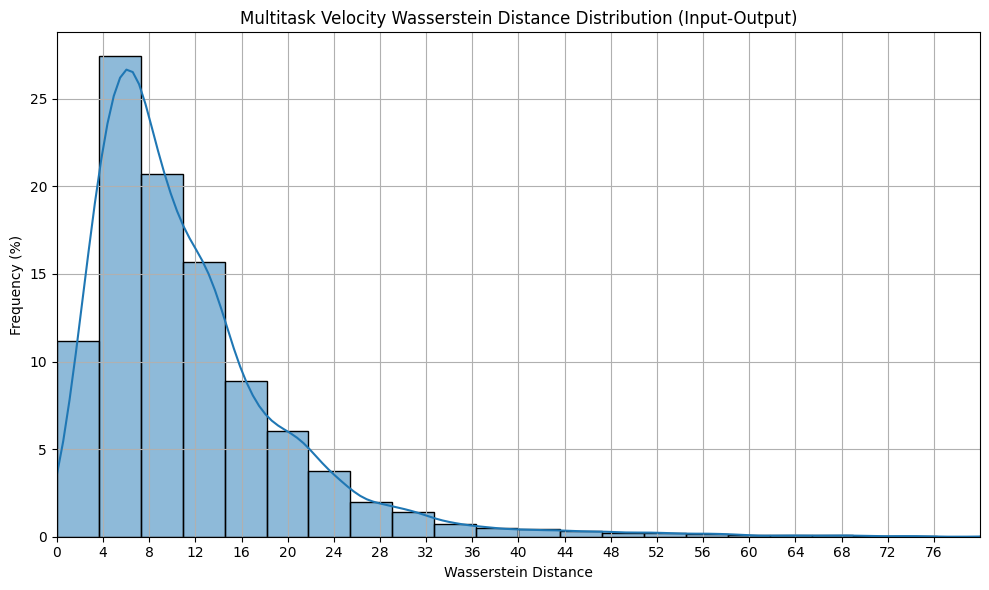

In [31]:
# emd histogram multi
emd_vals = multi_dist['vel_wasserstein']

plt.figure(figsize=(10, 6))
sns.histplot(emd_vals, bins=30, kde=True, stat='percent')
plt.title('Multitask Velocity Wasserstein Distance Distribution (Input-Output)')
plt.xlabel('Wasserstein Distance')
plt.xlim(0,80)
plt.xticks(np.arange(0, 80, 4))
plt.ylabel('Frequency (%)')
plt.grid()
plt.tight_layout()
plt.show()

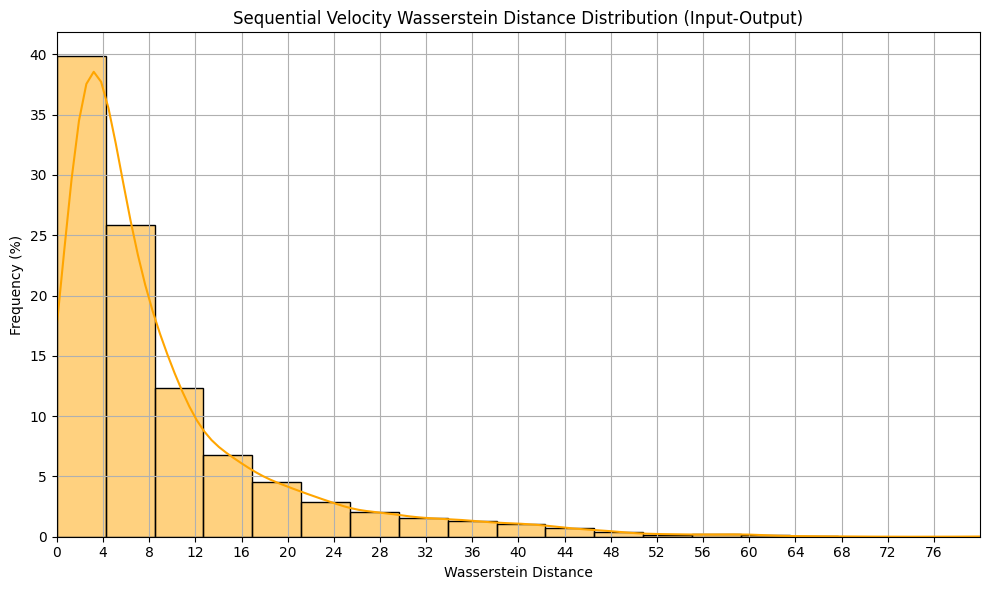

In [32]:
# emd histogram seq
emd_vals = seq_dist['vel_wasserstein']
plt.figure(figsize=(10, 6))
sns.histplot(emd_vals, bins=30, kde=True, stat='percent', color='orange')
plt.title('Sequential Velocity Wasserstein Distance Distribution (Input-Output)')
plt.xlabel('Wasserstein Distance')
plt.xlim(0, 80)
plt.xticks(np.arange(0, 80, 4))
plt.ylabel('Frequency (%)')
plt.grid()
plt.tight_layout()
plt.show()

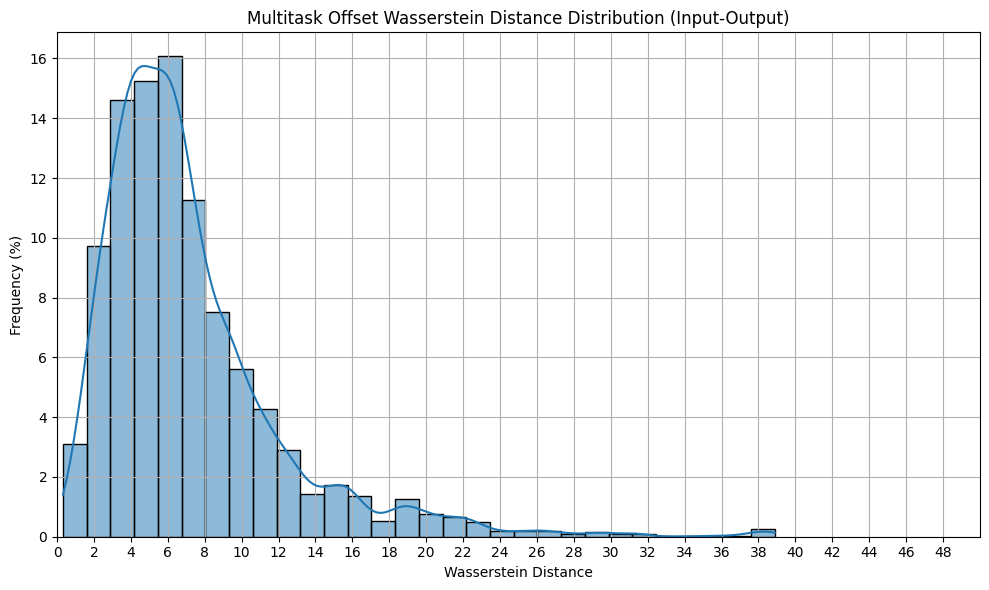

In [33]:
# offset emd multi
emd_vals = multi_dist['off_wasserstein']
plt.figure(figsize=(10, 6))
sns.histplot(emd_vals, bins=30, kde=True, stat='percent')
plt.title('Multitask Offset Wasserstein Distance Distribution (Input-Output)')
plt.xlabel('Wasserstein Distance')
plt.xlim(0, 50)
plt.xticks(np.arange(0, 50, 2))
plt.ylabel('Frequency (%)')
plt.grid()
plt.tight_layout()
plt.show()

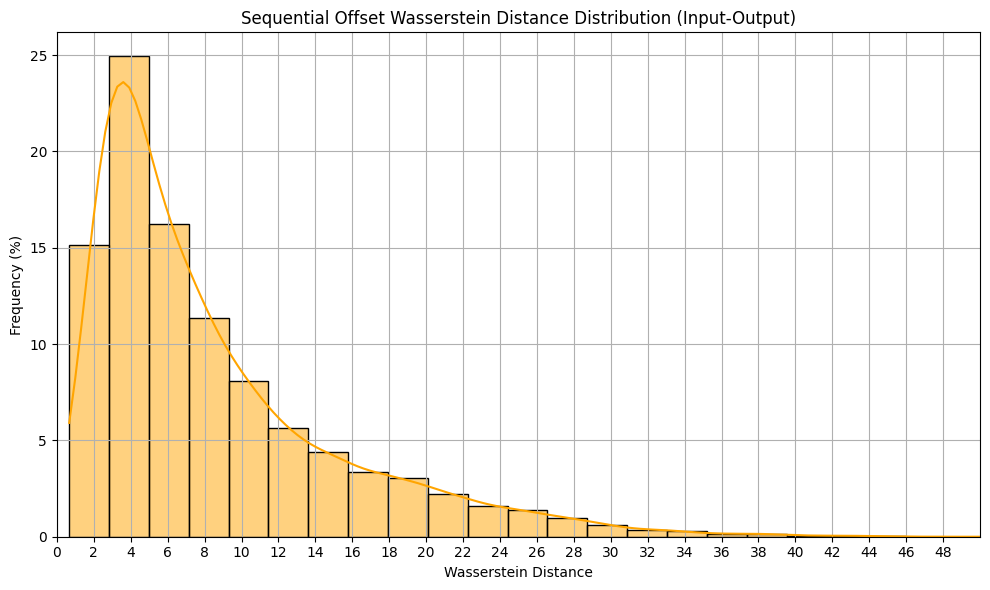

In [34]:
# offset emd seq
emd_vals = seq_dist['off_wasserstein']
plt.figure(figsize=(10, 6))
sns.histplot(emd_vals, bins=30, kde=True, stat='percent', color='orange')
plt.title('Sequential Offset Wasserstein Distance Distribution (Input-Output)')
plt.xlabel('Wasserstein Distance')
plt.xlim(0, 50)
plt.xticks(np.arange(0, 50, 2))
plt.ylabel('Frequency (%)')
plt.grid()
plt.tight_layout()
plt.show()

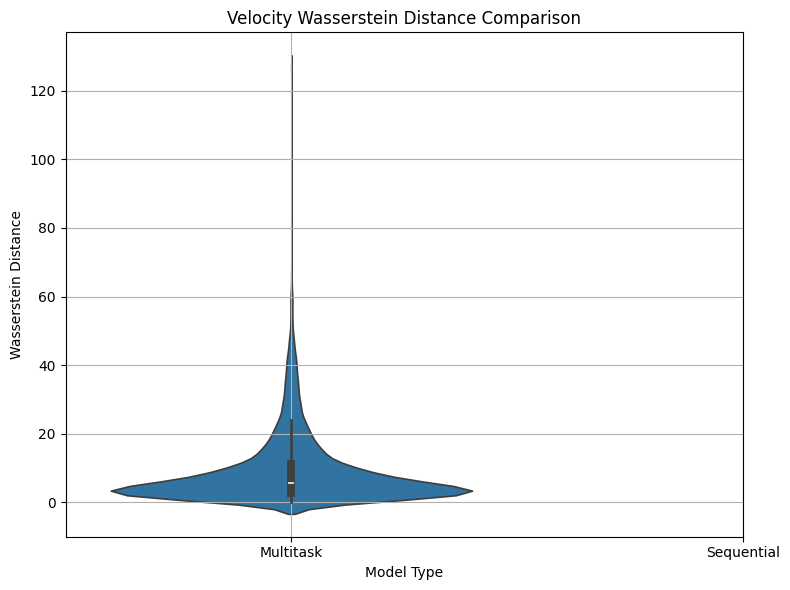

In [35]:
# wassersteim violin plot
plt.figure(figsize=(8, 6))
data_to_plot = [
    multi_dist['vel_wasserstein'],
    seq_dist['vel_wasserstein'],
]
sns.violinplot(data=data_to_plot)
plt.xticks([0, 1], ['Multitask', 'Sequential'])
plt.title('Velocity Wasserstein Distance Comparison')
plt.ylabel('Wasserstein Distance')
plt.xlabel('Model Type')
plt.grid()
plt.tight_layout()
plt.show()

## Dynamic Range Comparison

In [36]:
# compare velocity ranges

dynamic_ranges = stats_df[['vel_range', 'input_vel_range', 'off_range', 'input_off_range']]
dynamic_ranges["vel_range_diff"] = abs(dynamic_ranges['vel_range'] - dynamic_ranges['input_vel_range'])
dynamic_ranges["off_range_diff"] = abs(dynamic_ranges['off_range'] - dynamic_ranges['input_off_range'])
dynamic_ranges

C:\Users\minem\AppData\Local\Temp\ipykernel_30996\118704695.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dynamic_ranges["vel_range_diff"] = abs(dynamic_ranges['vel_range'] - dynamic_ranges['input_vel_range'])
C:\Users\minem\AppData\Local\Temp\ipykernel_30996\118704695.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dynamic_ranges["off_range_diff"] = abs(dynamic_ranges['off_range'] - dynamic_ranges['input_off_range'])


,vel_range,input_vel_range,off_range,input_off_range,vel_range_diff,off_range_diff
0,127,101,3,75,26,72
1,94,101,4,75,7,71
2,113,101,4,75,12,71
3,42,94,2,18,52,16
4,42,94,2,18,52,16
...,...,...,...,...,...,...
20294,82,90,15,21,8,6
20295,82,72,54,37,10,17
20296,50,15,15,37,35,22
20297,29,15,21,37,14,16


## Drum Pattern Comparison

In [37]:
def bit_indexes(n):
    return [i for i in range(n.bit_length()) if (n >> i) & 1]

In [38]:
example = eval_data.iloc[73]
example

input_dna                EvalData/OriginalInputs/dna/fbo_2_95.json
input_midi               EvalData/OriginalInputs/midi/fbo_2_95.mid
variation                                                        1
model                                     multitask_relgu_finetune
model_type                                               multitask
pretrain_type                                             finetune
temperature                                                    0.8
top_p                                                          0.8
max_tokens                                                     200
eval_type                                             creativeness
unit_count                                                     192
dna              EvalData/multitask_relgu_finetune_temp0.8_top_...
midi             EvalData/multitask_relgu_finetune_temp0.8_top_...
Name: 73, dtype: object

In [39]:
# plot drum patterns of input and some variations
with open(example['input_dna'], 'r') as f:
    input_data = json.load(f)[0]
with open(example['dna'], 'r') as f:
    output_data = json.load(f)[0]

input_units = input_data.get('DNAUnits', [])
output_units = output_data.get('DNAUnits', [])

len_input = len(input_units)
len_output = len(output_units)

gf = input_data.get('GridFactor', 4)
tpgu = input_data.get('TicksPerGridUnit', 120)
tpqn = input_data.get('TicksPerQuarterNote', 480)

input_pattern = np.zeros((len_input, len(InstrumentValues)))
output_pattern = np.zeros((len_output, len(InstrumentValues)))

for i, unit in enumerate(input_units):
    inst = unit.get('Value', 0)
    vel_dict = unit.get('VelocityPerValuePart', {})
    off_dict = unit.get('OffsetTicksPerValuePart', {})

    inst_parts = bit_indexes(inst)

    for part in inst_parts:
        input_pattern[i, part] = 1


for i, unit in enumerate(output_units):
    inst = unit.get('Value', 0)
    vel_dict = unit.get('VelocityPerValuePart', {})
    off_dict = unit.get('OffsetTicksPerValuePart', {})

    inst_parts = bit_indexes(inst)

    for part in inst_parts:
        output_pattern[i, part] = 1

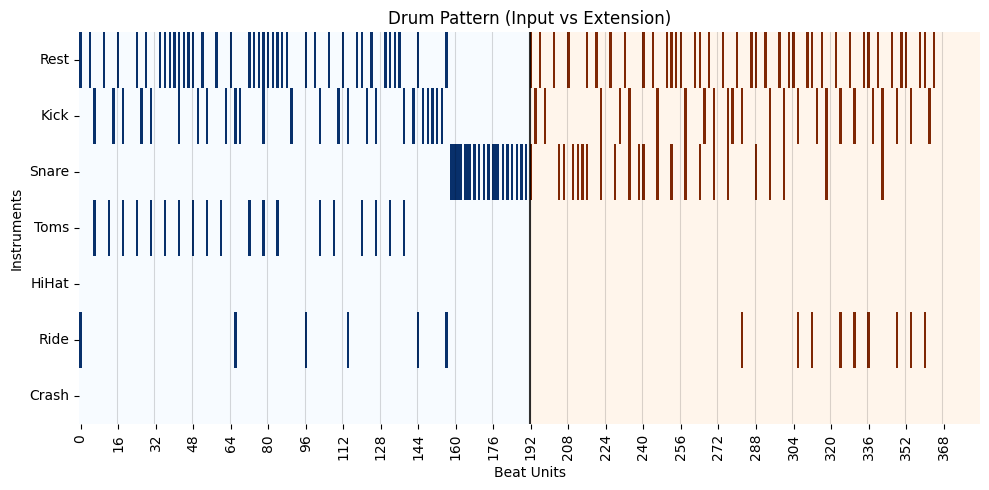

In [40]:
instrument_keys = [name for name, val in InstrumentValues.__members__.items()]

full_pattern = np.concatenate([input_pattern, output_pattern], axis=0)
total_steps = full_pattern.shape[0]

input_mask = np.zeros_like(full_pattern, dtype=bool)
extension_mask = np.zeros_like(full_pattern, dtype=bool)
input_mask[len_input:, :] = True
extension_mask[:len_input, :] = True

fig, ax = plt.subplots(figsize=(10, 5))

# Two heatmaps on the same Axes
sns.heatmap(full_pattern.T, mask=input_mask.T, cmap="Blues", cbar=False, ax=ax)
sns.heatmap(full_pattern.T, mask=extension_mask.T, cmap="Oranges", cbar=False, ax=ax)

# Labels
ax.set_yticks(np.arange(len(instrument_keys)) + 0.5)
ax.set_yticklabels(instrument_keys, rotation=0)
ax.set_xlabel("Beat Units")
ax.set_ylabel("Instruments")
ax.set_title("Drum Pattern (Input vs Extension)")

# Ensure full extent is visible
ax.set_xlim(0, total_steps)

# Input/extension boundary
ax.axvline(len_input, color="black", linewidth=1.5, alpha=0.8, zorder=10)

# Measure markers (every 16 steps)
steps_per_measure = 16
for x in range(steps_per_measure, total_steps, steps_per_measure):
    ax.axvline(x, color="black", linewidth=0.8, alpha=0.15, zorder=10)

xticks = np.arange(0, total_steps, steps_per_measure) + 0.5
xtick_labels = np.arange(0, total_steps, steps_per_measure)

ax.set_xticks(xticks)
ax.set_xticklabels(xtick_labels)

plt.tight_layout()
plt.show()

## Heatmaps, Distribution Plots

In [41]:
def build_instrument_lookup():
    instrument_mapping = RemappedInstrumentValues.__members__.items()
    return {val.value - 1: name for name, val in instrument_mapping}

def extract_events(eval_data, cache_csv_path="dna_event_cache.csv"):
    """
    Returns a long-form DataFrame with one row per (DNAUnit value part).
    Cached to CSV to avoid recomputing every run.
    """

    if os.path.exists(cache_csv_path):
        df = pd.read_csv(cache_csv_path)
        # optional: enforce dtypes
        df["model_type"] = df["model_type"].astype(str)
        df["direction"] = df["direction"].astype(str)
        return df

    rows = []

    for dna_path, input_dna_path, model_type in zip(
        eval_data["dna"], eval_data["input_dna"], eval_data["model_type"]
    ):
        # Keep your model_type branching if it mutates paths/behavior
        if model_type == "multitask":
            pass
        elif model_type == "sequential":
            pass

        with open(dna_path, "r") as f_out, open(input_dna_path, "r") as f_in:
            out_dna = json.load(f_out)[0]
            in_dna = json.load(f_in)[0]

        def add_rows(dna_obj, direction):
            for unit_idx, dna_unit in enumerate(dna_obj.get("DNAUnits", [])):
                off_dict = dna_unit.get("OffsetTicksPerValuePart", {}) or {}
                vel_dict = dna_unit.get("VelocityPerValuePart", {}) or {}

                inst = int(dna_unit.get("Value", 0) or 0)
                inst_parts = bit_indexes(inst)

                # Use the union of parts present in offset/velocity dicts (keys are "ValuePart" indices)
                # If keys are not consistent types, normalize to str for dict access.
                part_keys = set(map(str, off_dict.keys())) | set(map(str, vel_dict.keys()))

                # If those dicts are empty, still record instrument parts (no per-part timing/vel)
                if not part_keys:
                    for inst_part in inst_parts:
                        rows.append({
                            "model_type": model_type,
                            "direction": direction,          # "input" or "output"
                            "dna_path": dna_path,
                            "input_dna_path": input_dna_path,
                            "unit_idx": unit_idx,
                            "inst_part": inst_part,
                            "microtiming": np.nan,
                            "midi_velocity": np.nan,
                        })
                    return

                for k in part_keys:
                    o = off_dict.get(k, np.nan)
                    v = vel_dict.get(k, np.nan)

                    if pd.notna(v):
                        midi_velocity = int(round(float(v) * 128))
                        midi_velocity = max(0, min(127, midi_velocity))
                    else:
                        midi_velocity = np.nan

                    # One row per instrument part per value-part key (if you prefer 1 row per key,
                    # remove the inst_parts loop and store inst as raw instead.)
                    for inst_part in inst_parts:
                        rows.append({
                            "model_type": model_type,
                            "direction": direction,
                            "dna_path": dna_path,
                            "input_dna_path": input_dna_path,
                            "unit_idx": unit_idx,
                            "value_part_key": k,
                            "inst_part": inst_part,
                            "microtiming": o,
                            "midi_velocity": midi_velocity,
                        })

        add_rows(in_dna, "input")
        add_rows(out_dna, "output")

    df = pd.DataFrame(rows)
    df.to_csv(cache_csv_path, index=False)
    return df

In [42]:
def plot_instrument_distribution_by_model(
    df,
    title_prefix="Input vs Output Beat Event Distribution",
):
    instrument_lookup = build_instrument_lookup()

    # Canonical, fixed axis from the lookup
    instrument_indices = sorted(instrument_lookup.keys())
    instrument_names = [instrument_lookup[i] for i in instrument_indices]

    for model_type in ["multitask", "sequential"]:
        d = df[df["model_type"] == model_type].copy()

        # Keep only rows where we have a concrete instrument part
        d = d[pd.notna(d["inst_part"])].copy()
        d["inst_part"] = d["inst_part"].astype(int)

        # Long/tidy table of proportions by (direction, instrument)
        tidy_parts = []
        for direction in ["input", "output"]:
            counts = (
                d.loc[d["direction"] == direction, "inst_part"]
                .value_counts(normalize=True)
                .reindex(instrument_indices, fill_value=0.0)
            )
            tidy_parts.append(
                pd.DataFrame(
                    {
                        "direction": direction.capitalize(),
                        "inst_part": instrument_indices,
                        "proportion": counts.values,
                    }
                )
            )

        tidy = pd.concat(tidy_parts, ignore_index=True)

        # Map instruments to display labels and enforce axis order
        tidy["instrument_name"] = tidy["inst_part"].map(instrument_lookup)
        tidy["instrument_name"] = pd.Categorical(
            tidy["instrument_name"],
            categories=instrument_names,
            ordered=True,
        )

        fig, ax = plt.subplots(figsize=(10, 6))
        sns.barplot(
            data=tidy,
            x="instrument_name",
            y="proportion",
            hue="direction",
            ax=ax,
            dodge=True,
            errorbar=None,   # no CI bars (we're plotting exact proportions)
            palette={
                "Input": "#1F5AA6",
                "Output": "#6BAED6",
            }
            if model_type.lower() == "multitask" else
            {
                "Input": "#F28E2B",
                "Output": "#FFBE7D",
            }
        )

        ax.set_xlabel("Beat Event")
        ax.set_ylabel("Proportion")
        ax.set_title(f"{title_prefix} ({model_type})")
        ax.tick_params(axis="x", rotation=45)
        ax.grid(True)
        ax.legend(title=None)

        plt.tight_layout()
        plt.show()

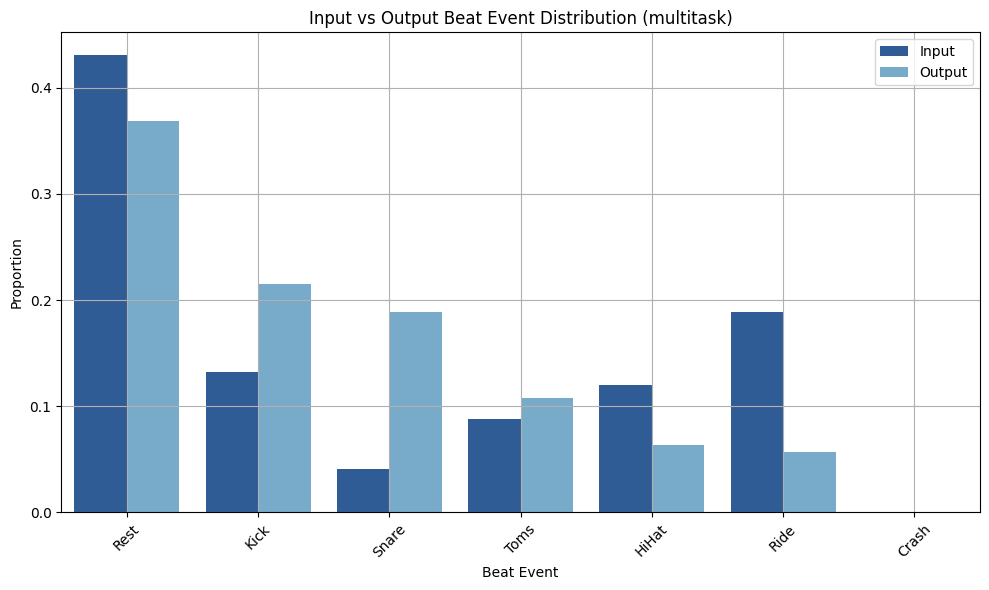

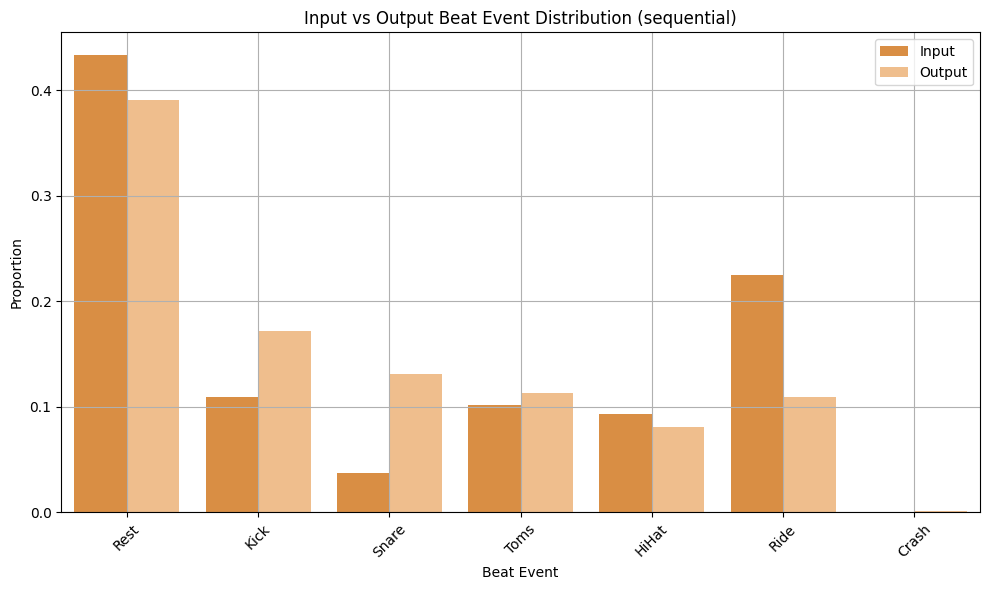

In [43]:
df_events = extract_events(eval_data, cache_csv_path="eval_dna_event_cache.csv")
MAX_INSTRUMENT_INDEX = 6

df_events = extract_events(
    eval_data,
    cache_csv_path="dna_event_cache.csv"
)

df_events = df_events[
    df_events["inst_part"].notna() &
    (df_events["inst_part"].astype(int) <= MAX_INSTRUMENT_INDEX)
]
plot_instrument_distribution_by_model(df_events)

In [44]:
df_events

,model_type,direction,dna_path,input_dna_path,unit_idx,value_part_key,inst_part,microtiming,midi_velocity
0,multitask,input,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/OriginalInputs/dna/fbo_10_10.json,0,32.0,0,1.0,127.0
1,multitask,input,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/OriginalInputs/dna/fbo_10_10.json,0,32.0,5,1.0,127.0
2,multitask,input,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/OriginalInputs/dna/fbo_10_10.json,0,1.0,0,1.0,127.0
3,multitask,input,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/OriginalInputs/dna/fbo_10_10.json,0,1.0,5,1.0,127.0
4,multitask,output,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/OriginalInputs/dna/fbo_10_10.json,0,32.0,0,1.0,127.0
...,...,...,...,...,...,...,...,...,...
273906,sequential,input,EvalData/sequential_large_finetune_maxtok400/d...,EvalData/OriginalInputs/dna/wb_724.json,12,2.0,3,8.0,127.0
273907,sequential,input,EvalData/sequential_large_finetune_maxtok400/d...,EvalData/OriginalInputs/dna/wb_724.json,12,8.0,1,5.0,127.0
273908,sequential,input,EvalData/sequential_large_finetune_maxtok400/d...,EvalData/OriginalInputs/dna/wb_724.json,12,8.0,3,5.0,127.0
273909,sequential,input,EvalData/sequential_large_finetune_maxtok400/d...,EvalData/OriginalInputs/dna/wb_724.json,13,1.0,0,-11.0,127.0


## Consistent Rhythm Pattern

In [45]:
# are the pulses consistent?

if Path('eval_pulse_deviations.csv').exists():
    pulse_dev_df = pd.read_csv('eval_pulse_deviations.csv')
else:
    pulse_deviations = []

    for dna, input_dna in zip(eval_data['dna'], eval_data['input_dna']):
        with open(dna, 'r') as f:
            out_dna = json.load(f)[0]
        with open(input_dna, 'r') as f:
            input_data = json.load(f)[0]

        input_pulses = []
        for dna_unit in input_data.get('DNAUnits', []):
            if not dna_unit.get('IsEmpty', True):
                input_pulses.append(1)
            else:
                input_pulses.append(0)

        output_pulses = []
        for dna_unit in out_dna.get('DNAUnits', []):
            if not dna_unit.get('IsEmpty', True):
                output_pulses.append(1)
            else:
                output_pulses.append(0)

        if len(input_pulses) > len(output_pulses):
            input_pulses = input_pulses[:len(output_pulses)]
        elif len(output_pulses) > len(input_pulses):
            output_pulses = output_pulses[:len(input_pulses)]

        hamming_distance = sum(i != o for i, o in zip(input_pulses, output_pulses))
        corr = np.correlate(output_pulses, input_pulses, mode='full')
        shift = np.argmax(corr) - (len(input_pulses) - 1)
        per_pos = [abs(i-o) for i,o in zip(input_pulses, output_pulses)]
        deviation_count = sum(per_pos)
        devation_ratio = deviation_count / len(output_pulses)

        pulse_deviations.append({
            'dna_file': dna,
            'input_dna_file': input_dna,
            'sequence_length': len(input_pulses),
            'hamming_distance': hamming_distance,
            'shift': shift,
            'deviation_count': deviation_count,
            'per_position': per_pos,
            'deviation_ratio': devation_ratio,
        })

    pulse_dev_df = pd.DataFrame(pulse_deviations)
    pulse_dev_df.to_csv('eval_pulse_deviations.csv')


In [46]:
pulse_dev_df

,Unnamed: 0,dna_file,input_dna_file,sequence_length,hamming_distance,shift,deviation_count,per_position,deviation_ratio
0,0,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/OriginalInputs/dna/fbo_10_10.json,144,20,-6,20,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.138889
1,1,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/OriginalInputs/dna/fbo_10_10.json,144,31,0,31,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, ...",0.215278
2,2,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/OriginalInputs/dna/fbo_10_10.json,160,46,0,46,"[0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, ...",0.287500
3,3,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/OriginalInputs/dna/fbo_10_16.json,128,46,-16,46,"[0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, ...",0.359375
4,4,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/OriginalInputs/dna/fbo_10_16.json,128,45,-16,45,"[0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, ...",0.351562
...,...,...,...,...,...,...,...,...,...
20294,20294,EvalData/sequential_large_finetune_maxtok400/d...,EvalData/OriginalInputs/dna/wb_6939.json,33,3,0,3,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.090909
20295,20295,EvalData/sequential_large_finetune_maxtok400/d...,EvalData/OriginalInputs/dna/wb_6967.json,64,4,0,4,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.062500
20296,20296,EvalData/sequential_large_finetune_maxtok400/d...,EvalData/OriginalInputs/dna/wb_724.json,32,5,1,5,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.156250
20297,20297,EvalData/sequential_large_finetune_maxtok400/d...,EvalData/OriginalInputs/dna/wb_724.json,32,5,1,5,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.156250


In [47]:
multi_pulse_dev = pulse_dev_df.merge(
    multi_outputs,
    left_on="dna_file",
    right_on="dna",
    how="inner",
    validate="one_to_one"
)

seq_pulse_dev = pulse_dev_df.merge(
    sequential_outputs,
    left_on="dna_file",
    right_on="dna",
    how="inner",
    validate="one_to_one"
)

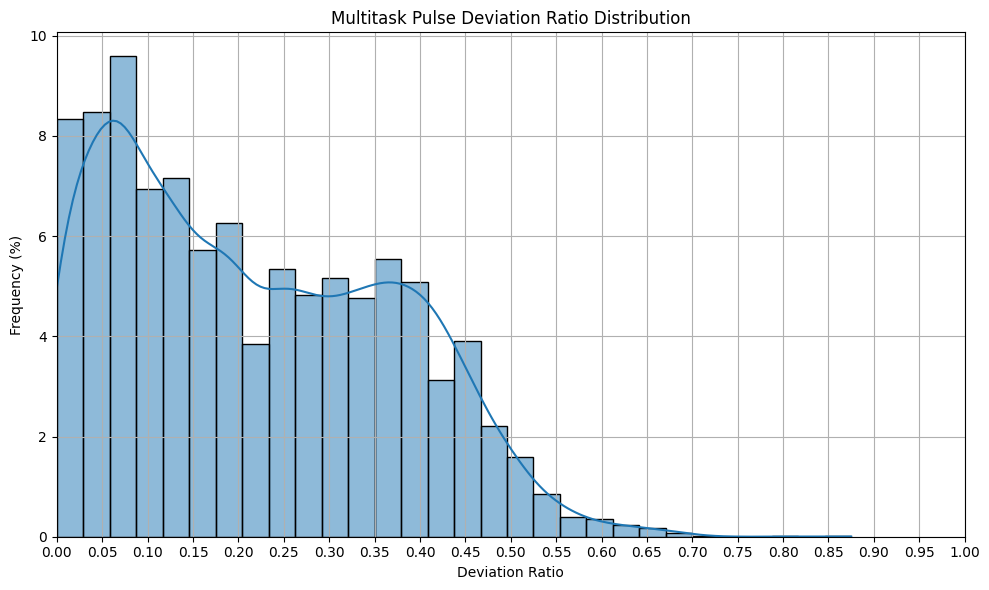

In [48]:
# plot histogram of deviation ratios for multitask
dev_ratios = multi_pulse_dev['deviation_ratio']
plt.figure(figsize=(10, 6))
sns.histplot(dev_ratios, bins=30, kde=True, stat='percent')
plt.title('Multitask Pulse Deviation Ratio Distribution')
plt.xlabel('Deviation Ratio')
plt.xticks(np.arange(0, 1.05, 0.05))
plt.xlim([0, 1])
plt.ylabel('Frequency (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

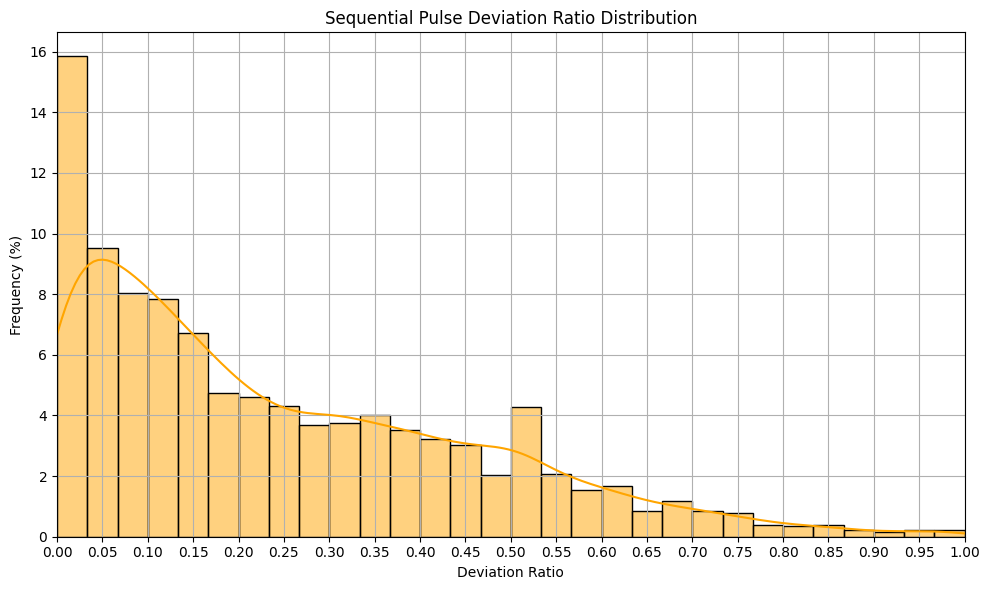

In [49]:
# plot histogram of deviation ratios for sequential
dev_ratios = seq_pulse_dev['deviation_ratio']
plt.figure(figsize=(10, 6))
sns.histplot(dev_ratios, bins=30, kde=True, stat='percent', color='orange')
plt.title('Sequential Pulse Deviation Ratio Distribution')
plt.xlabel('Deviation Ratio')
plt.xticks(np.arange(0, 1.05, 0.05))
plt.xlim([0, 1])
plt.ylabel('Frequency (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\minem\AppData\Local\Temp\ipykernel_30996\4174344665.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=['Multitask', 'Sequential'])


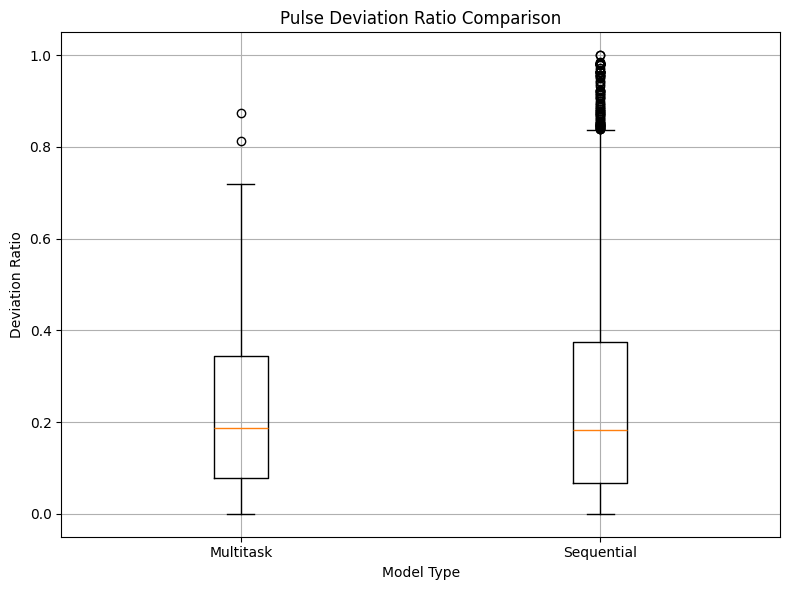

In [50]:
# pulse deviation boxplots
plt.figure(figsize=(8, 6))
data_to_plot = [
    multi_pulse_dev['deviation_ratio'],
    seq_pulse_dev['deviation_ratio'],
]
plt.boxplot(data_to_plot, labels=['Multitask', 'Sequential'])
plt.title('Pulse Deviation Ratio Comparison')
plt.ylabel('Deviation Ratio')
plt.xlabel('Model Type')
plt.grid()
plt.tight_layout()
plt.show()

C:\Users\minem\AppData\Local\Temp\ipykernel_30996\4234219239.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


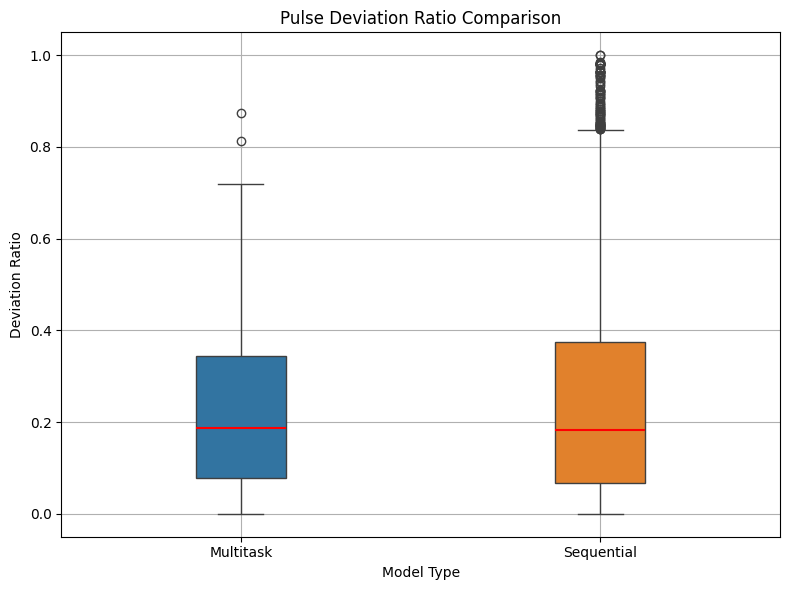

In [51]:
# Prepare data
df = pd.DataFrame({
    "Deviation Ratio": pd.concat([
        multi_pulse_dev["deviation_ratio"],
        seq_pulse_dev["deviation_ratio"]
    ], ignore_index=True),
    "Model Type": (
        ["Multitask"] * len(multi_pulse_dev) +
        ["Sequential"] * len(seq_pulse_dev)
    )
})

# Boxplot with emphasized median
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df,
    x="Model Type",
    y="Deviation Ratio",
    width=0.25,
    palette={
        "Multitask": "#1f77b4",
        "Sequential": "#ff7f0e"
    },
    medianprops={
        "color": "red",
        "linewidth": 1.5
    }
)

plt.title("Pulse Deviation Ratio Comparison")
plt.xlabel("Model Type")
plt.ylabel("Deviation Ratio")
plt.grid()
plt.tight_layout()
plt.show()

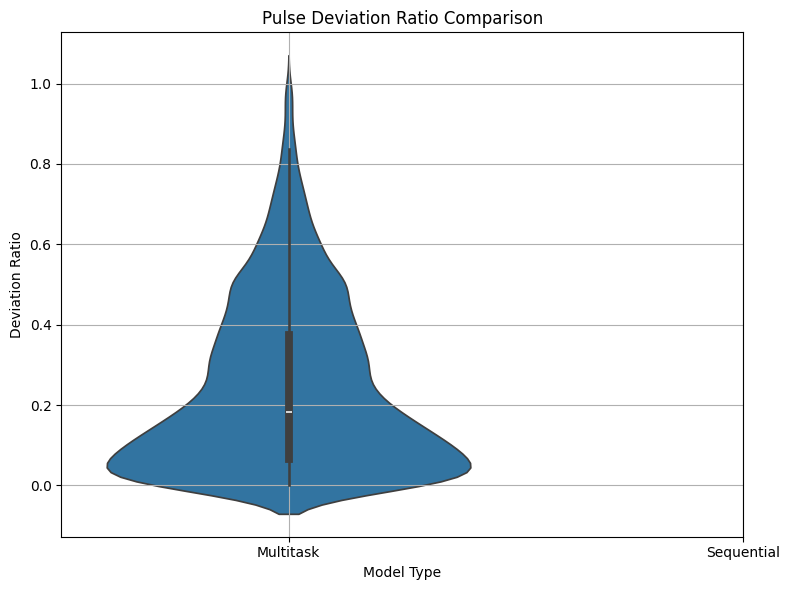

In [52]:
# violin plot of pulse deviation ratios
plt.figure(figsize=(8, 6))
data_to_plot = [
    multi_pulse_dev['deviation_ratio'],
    seq_pulse_dev['deviation_ratio'],
]
sns.violinplot(data=data_to_plot)
plt.xticks([0, 1], ['Multitask', 'Sequential'])
plt.title('Pulse Deviation Ratio Comparison')
plt.ylabel('Deviation Ratio')
plt.xlabel('Model Type')
plt.grid()
plt.tight_layout()
plt.show()

## Comparing Parameter settings (temp, top-p, max_tokens)

In [53]:
# Memory usage, processing power required,...
eval_data

,input_dna,input_midi,variation,model,model_type,pretrain_type,temperature,top_p,max_tokens,eval_type,unit_count,dna,midi
0,EvalData/OriginalInputs/dna/fbo_10_10.json,EvalData/OriginalInputs/midi/fbo_10_10.mid,0,multitask_relgu_finetune,multitask,finetune,0.8,0.8,200,creativeness,144,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/multitask_relgu_finetune_temp0.8_top_...
1,EvalData/OriginalInputs/dna/fbo_10_10.json,EvalData/OriginalInputs/midi/fbo_10_10.mid,1,multitask_relgu_finetune,multitask,finetune,0.8,0.8,200,creativeness,144,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/multitask_relgu_finetune_temp0.8_top_...
2,EvalData/OriginalInputs/dna/fbo_10_10.json,EvalData/OriginalInputs/midi/fbo_10_10.mid,2,multitask_relgu_finetune,multitask,finetune,0.8,0.8,200,creativeness,160,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/multitask_relgu_finetune_temp0.8_top_...
3,EvalData/OriginalInputs/dna/fbo_10_16.json,EvalData/OriginalInputs/midi/fbo_10_16.mid,0,multitask_relgu_finetune,multitask,finetune,0.8,0.8,200,creativeness,128,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/multitask_relgu_finetune_temp0.8_top_...
4,EvalData/OriginalInputs/dna/fbo_10_16.json,EvalData/OriginalInputs/midi/fbo_10_16.mid,1,multitask_relgu_finetune,multitask,finetune,0.8,0.8,200,creativeness,128,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/multitask_relgu_finetune_temp0.8_top_...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20294,EvalData/OriginalInputs/dna/wb_6939.json,EvalData/OriginalInputs/midi/wb_6939.mid,2,sequential_large_finetune,sequential,finetune,1.0,0.9,400,sequence_length,33,EvalData/sequential_large_finetune_maxtok400/d...,EvalData/sequential_large_finetune_maxtok400/m...
20295,EvalData/OriginalInputs/dna/wb_6967.json,EvalData/OriginalInputs/midi/wb_6967.mid,2,sequential_large_finetune,sequential,finetune,1.0,0.9,400,sequence_length,65,EvalData/sequential_large_finetune_maxtok400/d...,EvalData/sequential_large_finetune_maxtok400/m...
20296,EvalData/OriginalInputs/dna/wb_724.json,EvalData/OriginalInputs/midi/wb_724.mid,0,sequential_large_finetune,sequential,finetune,1.0,0.9,400,sequence_length,35,EvalData/sequential_large_finetune_maxtok400/d...,EvalData/sequential_large_finetune_maxtok400/m...
20297,EvalData/OriginalInputs/dna/wb_724.json,EvalData/OriginalInputs/midi/wb_724.mid,1,sequential_large_finetune,sequential,finetune,1.0,0.9,400,sequence_length,67,EvalData/sequential_large_finetune_maxtok400/d...,EvalData/sequential_large_finetune_maxtok400/m...


In [54]:
param_groups = eval_data.groupby(['temperature', 'top_p', 'max_tokens']).size().reset_index(name='count')
param_groups

,temperature,top_p,max_tokens,count
0,0.8,0.80,200,2037
1,0.8,0.90,200,2032
2,0.8,0.95,200,2011
3,1.0,0.80,200,2009
4,1.0,0.90,100,968
5,1.0,0.90,200,2914
6,1.0,0.90,400,958
7,1.0,0.95,200,1934
8,1.2,0.80,200,1909
9,1.2,0.90,200,1777


In [67]:

print(seq_stats['vel_std'].mean())
print(multi_stats['vel_std'].mean())
print(seq_stats['off_std'].mean())
print(multi_stats["off_std"].mean())

print(len(seq_stats[seq_stats['vel_std'] > 0]) / len(seq_stats))
print(len(multi_stats[multi_stats['vel_std'] > 0]) / len(multi_stats))
print(len(seq_stats[seq_stats['off_std'] > 0]) / len(seq_stats))
print(len(multi_stats[multi_stats['off_std'] > 0]) / len(multi_stats))



19.119169503594858
21.7969633695934
10.011539898140494
1.2932183314308252
0.8871281984673334
0.9959523809523809
0.9974022600337706
0.9631746031746031


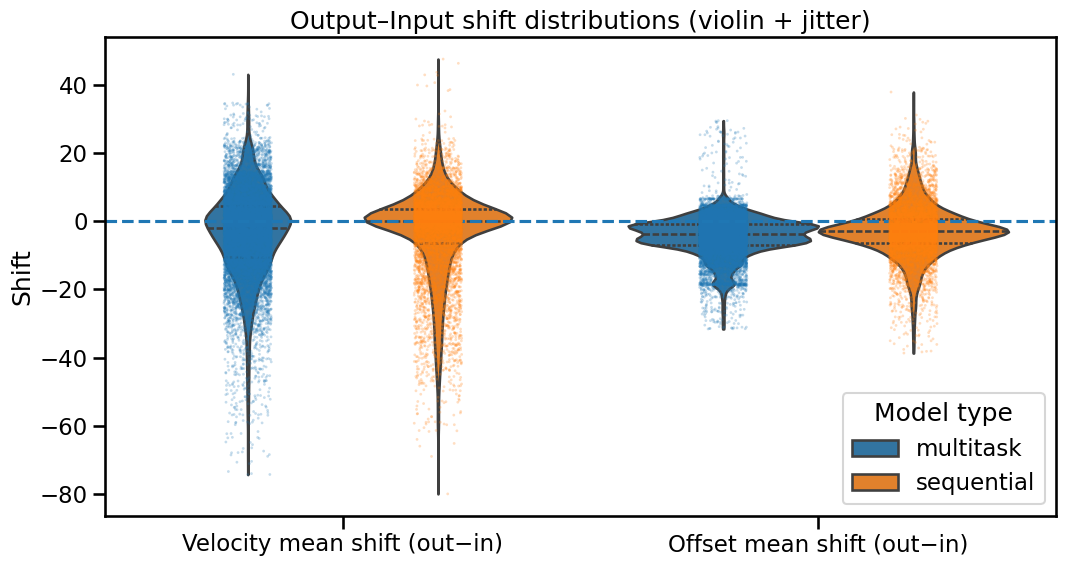

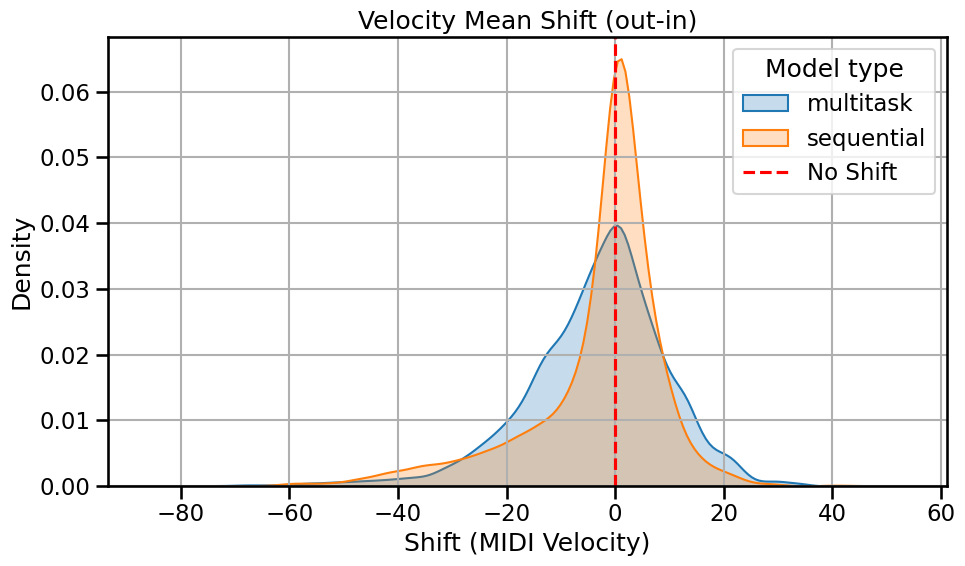

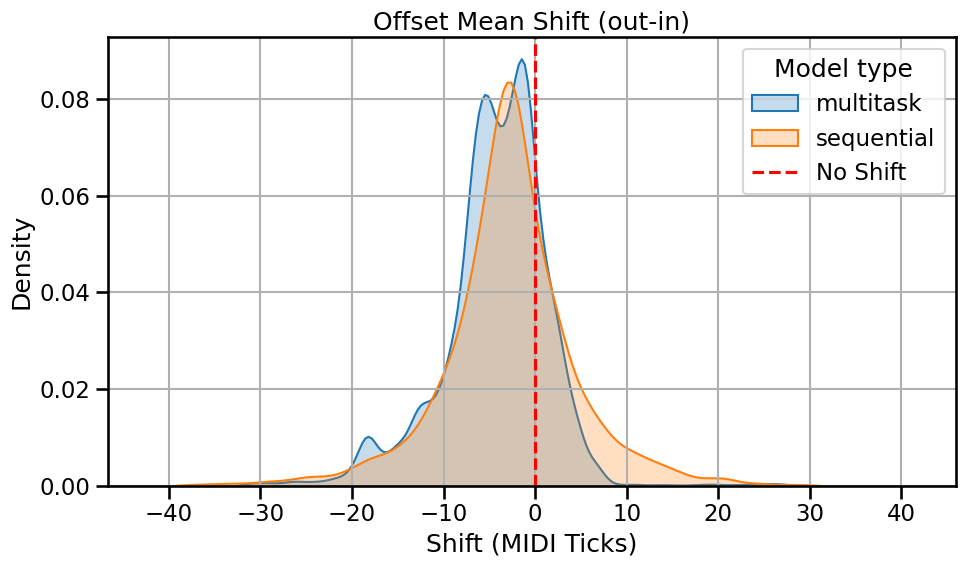

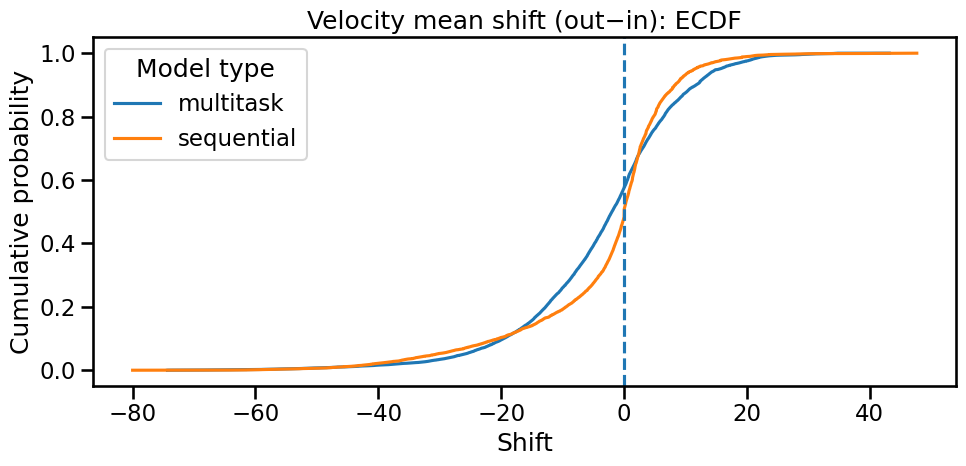

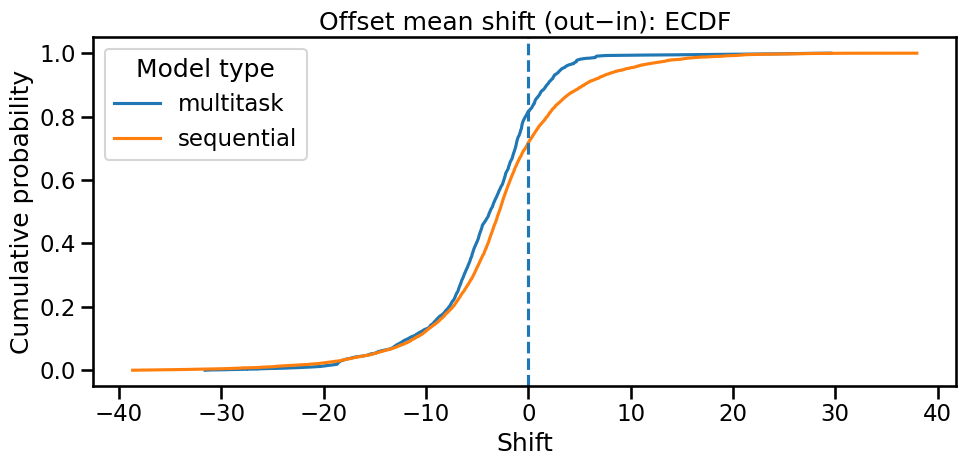

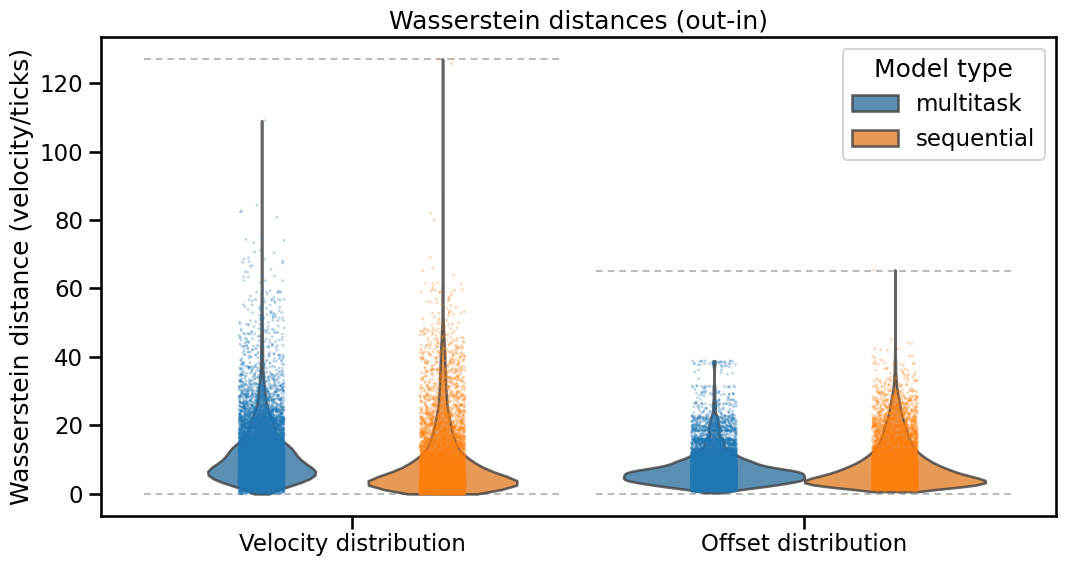

<Figure size 1000x600 with 0 Axes>

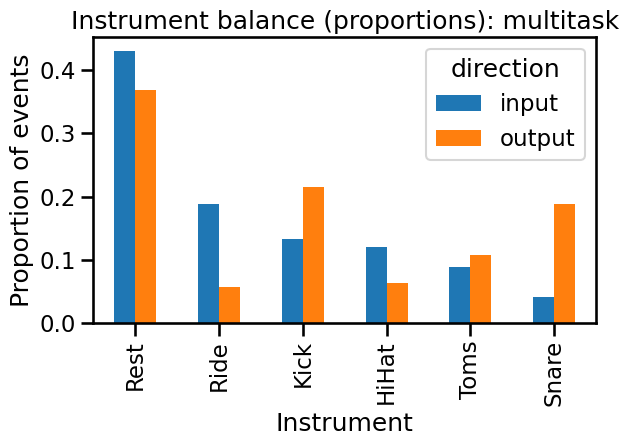

<Figure size 1000x600 with 0 Axes>

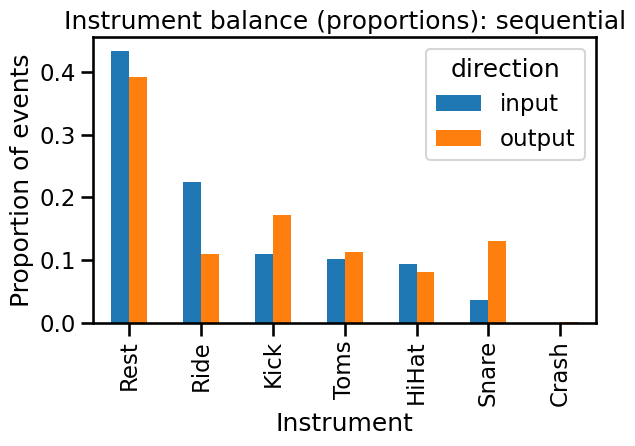

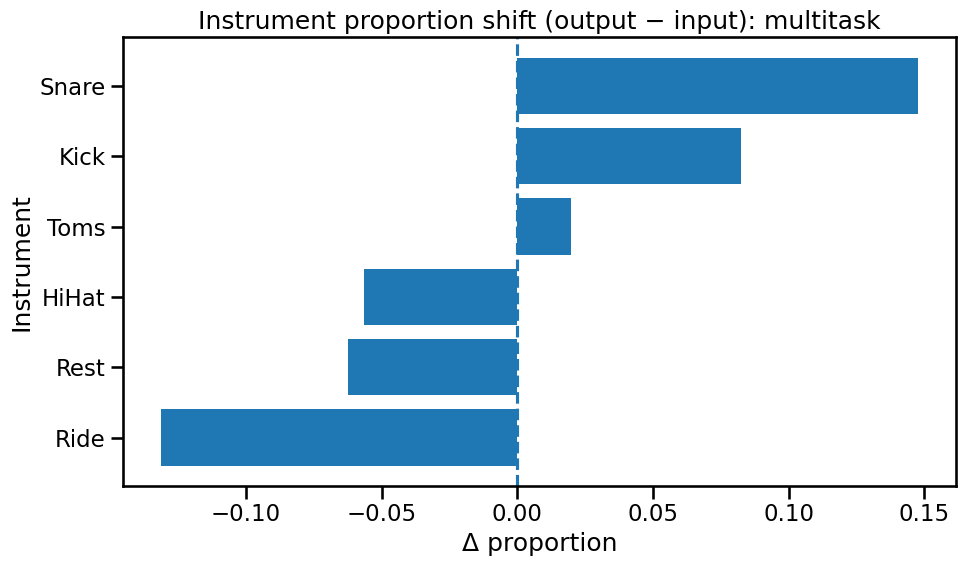

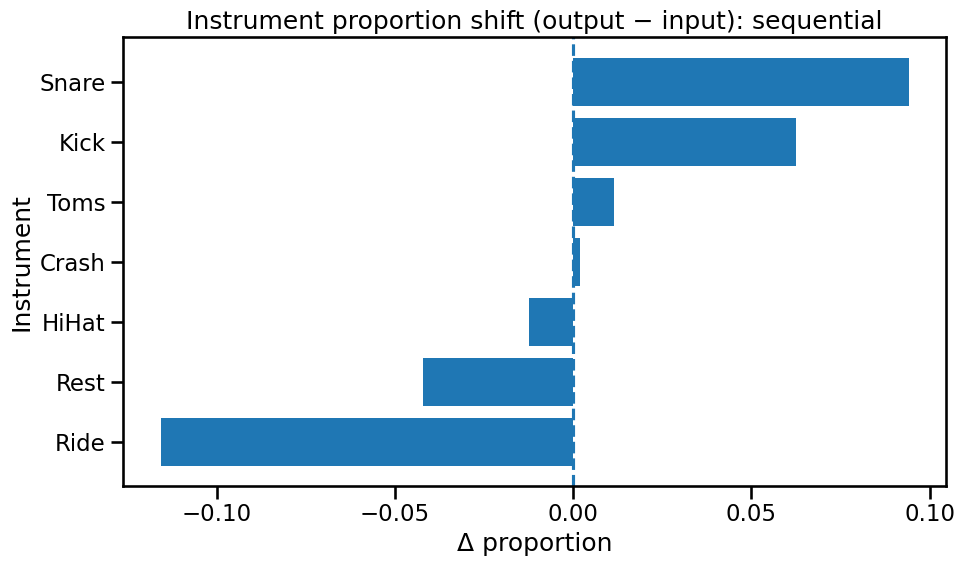

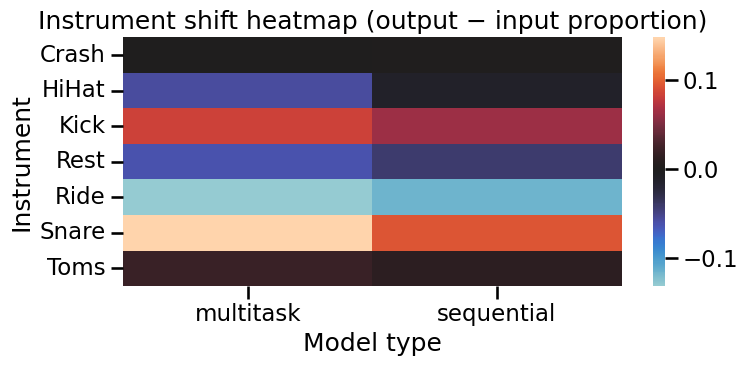

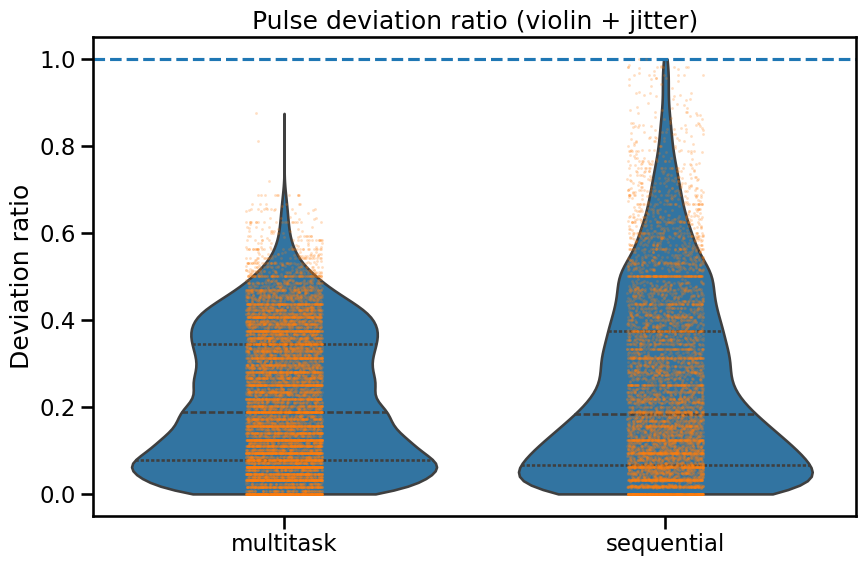

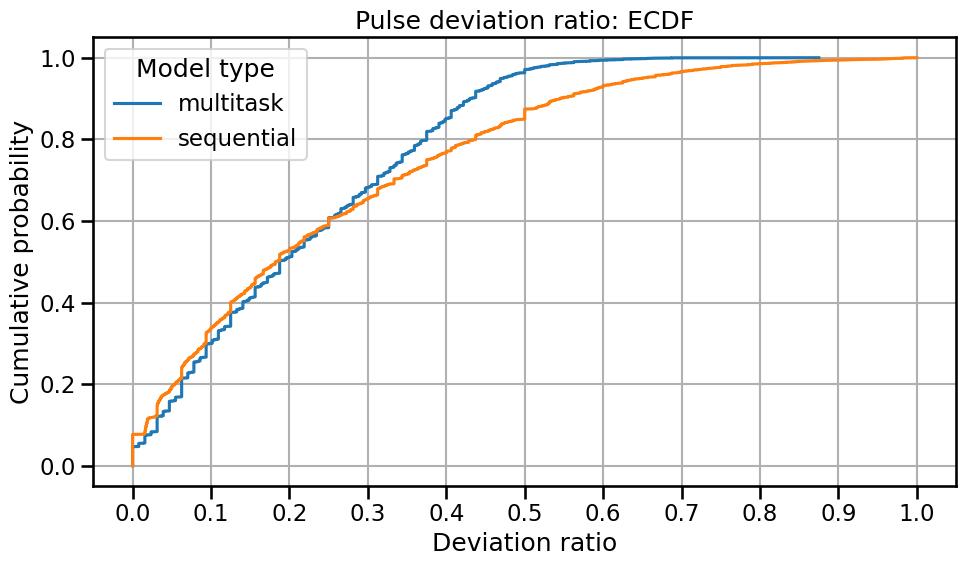

In [56]:
# Alternative visualisations (drop-in cell)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("talk")

def _ecdf(x):
    x = np.asarray(pd.Series(x).dropna())
    if x.size == 0:
        return np.array([]), np.array([])
    x = np.sort(x)
    y = np.arange(1, x.size + 1) / x.size
    return x, y

# ---------------------------------------------------------------------
# 1) Paired shift plots (Output - Input) for velocity mean and offset mean
# ---------------------------------------------------------------------
needed = {"multi_stats", "seq_stats"}
missing = [v for v in needed if v not in globals()]
if missing:
    print(f"Skipping shift plots because missing objects: {missing}")
else:
    shift_df = pd.concat(
        [
            pd.DataFrame(
                {
                    "model_type": "multitask",
                    "vel_shift": multi_stats["vel_mean"] - multi_stats["input_vel_mean"],
                    "off_shift": multi_stats["off_mean"] - multi_stats["input_off_mean"],
                }
            ),
            pd.DataFrame(
                {
                    "model_type": "sequential",
                    "vel_shift": seq_stats["vel_mean"] - seq_stats["input_vel_mean"],
                    "off_shift": seq_stats["off_mean"] - seq_stats["input_off_mean"],
                }
            ),
        ],
        ignore_index=True,
    )

    # Optional: apply your notebook's clipping conventions (edit or remove as desired)
    shift_df.loc[shift_df["vel_shift"] < -80, "vel_shift"] = np.nan
    shift_df.loc[shift_df["off_shift"].abs() > 40, "off_shift"] = np.nan

    shift_long = shift_df.melt(
        id_vars="model_type",
        value_vars=["vel_shift", "off_shift"],
        var_name="metric",
        value_name="shift",
    )
    shift_long["metric"] = shift_long["metric"].map(
        {"vel_shift": "Velocity mean shift (out−in)", "off_shift": "Offset mean shift (out−in)"}
    )

    # Violin + jitter (paired-difference distribution)
    plt.figure(figsize=(11, 6))
    sns.violinplot(data=shift_long, x="metric", y="shift", hue="model_type", cut=0, inner="quartile")
    sns.stripplot(
        data=shift_long, x="metric", y="shift", hue="model_type",
        dodge=True, alpha=0.25, size=2, linewidth=0
    )
    plt.axhline(0, linestyle="--")
    plt.title("Output–Input shift distributions (violin + jitter)")
    plt.xlabel("")
    plt.ylabel("Shift")
    # De-duplicate legend (because we used hue twice)
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles[:2], labels[:2], title="Model type", loc="best")
    plt.tight_layout()
    plt.show()

    # KDE overlays (one figure per metric)
    for col, title in [
        ("vel_shift", "Velocity Mean Shift (out-in)"),
        ("off_shift", "Offset Mean Shift (out-in)"),
    ]:
        plt.figure(figsize=(10, 6))
        for mt in ["multitask", "sequential"]:
            x = shift_df.loc[shift_df["model_type"] == mt, col].dropna()
            if len(x) > 1:
                sns.kdeplot(x=x, label=mt, fill=True)
        plt.axvline(0, linestyle="--", color="red", label="No Shift")
        plt.title(title)
        if col == "vel_shift":
            plt.xlabel("Shift (MIDI Velocity)")
        else:
            plt.xlabel("Shift (MIDI Ticks)")
            plt.xticks(range(-40,50, 10))
        plt.ylabel("Density")
        plt.legend(title="Model type")
        plt.grid()
        plt.tight_layout()
        plt.show()

    # ECDF overlays (stable comparisons; answers "fraction within threshold")
    for col, title in [
        ("vel_shift", "Velocity mean shift (out−in): ECDF"),
        ("off_shift", "Offset mean shift (out−in): ECDF"),
    ]:
        plt.figure(figsize=(10, 5))
        for mt in ["multitask", "sequential"]:
            x = shift_df.loc[shift_df["model_type"] == mt, col]
            xs, ys = _ecdf(x)
            if xs.size:
                plt.plot(xs, ys, label=mt)
        plt.axvline(0, linestyle="--")
        plt.title(title)
        plt.xlabel("Shift")
        plt.ylabel("Cumulative probability")
        plt.legend(title="Model type")
        plt.tight_layout()
        plt.show()

# ---------------------------------------------------------------------
# 2) Wasserstein distance: violin + points (more informative than violin alone)
# ---------------------------------------------------------------------
needed = {"multi_dist", "seq_dist"}
missing = [v for v in needed if v not in globals()]
if missing:
    print(f"Skipping Wasserstein plots because missing objects: {missing}")
else:
    wdf = pd.concat(
        [
            pd.DataFrame(
                {
                    "model_type": "multitask",
                    "vel_wasserstein": multi_dist["vel_wasserstein"],
                    "off_wasserstein": multi_dist["off_wasserstein"],
                }
            ),
            pd.DataFrame(
                {
                    "model_type": "sequential",
                    "vel_wasserstein": seq_dist["vel_wasserstein"],
                    "off_wasserstein": seq_dist["off_wasserstein"],
                }
            ),
        ],
        ignore_index=True,
    )
    wlong = wdf.melt("model_type", var_name="metric", value_name="wasserstein")
    wlong["metric"] = wlong["metric"].map(
        {"vel_wasserstein": "Velocity distribution", "off_wasserstein": "Offset distribution"}
    )

    plt.figure(figsize=(11, 6))
    sns.violinplot(data=wlong, x="metric", y="wasserstein", hue="model_type", alpha=0.8, cut=0, inner=None)
    sns.stripplot(
        data=wlong, x="metric", y="wasserstein", hue="model_type",
        dodge=True, alpha=0.3, size=2, linewidth=0
    )

    from matplotlib.lines import Line2D

    ax = plt.gca()

    # x positions for the two categories on the x-axis
    # (assumes order is ["Velocity distribution", "Offset distribution"])
    xt = ax.get_xticks()
    cat_width = 0.46  # half-width of the segment; tweak 0.40–0.49 to taste

    # subtle styling
    range_color = "0.55"  # mid-grey
    range_kw = dict(colors=range_color, linestyles=(0, (4, 3)), linewidth=1.2, alpha=0.7, zorder=0)

    # Velocity distribution
    xv = xt[0]
    ax.hlines([0, 127], xmin=xv - cat_width, xmax=xv + cat_width, **range_kw)

    # Offset distribution
    xo = xt[1]
    ax.hlines([0, 65], xmin=xo - cat_width, xmax=xo + cat_width, **range_kw)

    # Optional: add a legend entry for the dashed bounds
    handles, labels = ax.get_legend_handles_labels()
    bounds_handle = Line2D([0], [0], color=range_color, lw=1.2, linestyle=(0, (4, 3)), alpha=0.7)
    ax.legend(handles[:2] + [bounds_handle], labels[:2] + ["Value range"], title="Model type", loc="best")

    plt.title("Wasserstein distances (out-in)")
    plt.xlabel("")
    plt.ylabel("Wasserstein distance (velocity/ticks)")
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles[:2], labels[:2], title="Model type", loc="best")

    plt.gray()
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------------------
# 3) Instrument distribution shifts: normalized stacked bars + diverging bars + heatmap
#    Uses df_events produced by extract_events(...) in your notebook.
# ---------------------------------------------------------------------
needed = {"df_events"}
missing = [v for v in needed if v not in globals()]
if missing:
    print(f"Skipping instrument-shift plots because missing objects: {missing}")
else:
    # Expect df_events columns: model_type, direction ('input'/'output'), inst_part
    _df = df_events.copy()
    _df = _df[_df["direction"].isin(["input", "output"]) & _df["model_type"].isin(["multitask", "sequential"])]
    _df["inst_part"] = _df["inst_part"].astype(int)

    # Build labels if your instrument lookup exists; otherwise use inst_part integers
    inst_lookup = globals().get("build_instrument_lookup", None)
    if callable(inst_lookup):
        inst_map = inst_lookup()
        _df["instrument"] = _df["inst_part"].map(lambda k: inst_map.get(k, f"inst_{k}"))
    else:
        _df["instrument"] = _df["inst_part"].map(lambda k: f"inst_{k}")

    counts = (
        _df.groupby(["model_type", "direction", "instrument"])
        .size()
        .reset_index(name="n")
    )

    # Normalize within (model_type, direction) to compare balance
    counts["prop"] = counts["n"] / counts.groupby(["model_type", "direction"])["n"].transform("sum")

    # Normalized stacked bars: input vs output, faceted by model_type (implemented as two separate plots)
    for mt in ["multitask", "sequential"]:
        pivot = (
            counts[counts["model_type"] == mt]
            .pivot_table(index="instrument", columns="direction", values="prop", fill_value=0)
            .sort_values(by="input", ascending=False)
        )
        plt.figure(figsize=(10, 6))
        pivot.plot(kind="bar", stacked=False)  # side-by-side proportions
        plt.title(f"Instrument balance (proportions): {mt}")
        plt.xlabel("Instrument")
        plt.ylabel("Proportion of events")
        plt.tight_layout()
        plt.show()

    # Diverging bars: (output − input) proportion per instrument, by model
    pivot2 = (
        counts.pivot_table(index=["model_type", "instrument"], columns="direction", values="prop", fill_value=0)
        .reset_index()
    )
    pivot2["delta"] = pivot2["output"] - pivot2["input"]

    for mt in ["multitask", "sequential"]:
        d = pivot2[pivot2["model_type"] == mt].sort_values("delta")
        plt.figure(figsize=(10, 6))
        plt.barh(d["instrument"], d["delta"])
        plt.axvline(0, linestyle="--")
        plt.title(f"Instrument proportion shift (output − input): {mt}")
        plt.xlabel("Δ proportion")
        plt.ylabel("Instrument")
        plt.tight_layout()
        plt.show()

    # Heatmap: instruments × model_type of delta proportion
    heat = pivot2.pivot_table(index="instrument", columns="model_type", values="delta", fill_value=0)
    plt.figure(figsize=(8, max(4, 0.35 * len(heat))))
    sns.heatmap(heat, annot=False, center=0)
    plt.title("Instrument shift heatmap (output − input proportion)")
    plt.xlabel("Model type")
    plt.ylabel("Instrument")
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------------------
# 4) Pulse deviation ratio: single violin + jitter and ECDF
# ---------------------------------------------------------------------
needed = {"multi_pulse_dev", "seq_pulse_dev"}
missing = [v for v in needed if v not in globals()]
if missing:
    print(f"Skipping pulse deviation plots because missing objects: {missing}")
else:
    p = pd.concat(
        [
            pd.DataFrame({"model_type": "multitask", "deviation_ratio": multi_pulse_dev["deviation_ratio"]}),
            pd.DataFrame({"model_type": "sequential", "deviation_ratio": seq_pulse_dev["deviation_ratio"]}),
        ],
        ignore_index=True,
    ).dropna()

    plt.figure(figsize=(9, 6))

    sns.violinplot(data=p, x="model_type", y="deviation_ratio", cut=0, inner="quartile")
    sns.stripplot(data=p, x="model_type", y="deviation_ratio", alpha=0.25, size=2, linewidth=0)
    plt.axhline(1.0, linestyle="--")
    plt.title("Pulse deviation ratio (violin + jitter)")
    plt.xlabel("")
    plt.ylabel("Deviation ratio")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    for mt in ["multitask", "sequential"]:
        xs, ys = _ecdf(p.loc[p["model_type"] == mt, "deviation_ratio"])
        if xs.size:
            plt.plot(xs, ys, label=mt)
    plt.title("Pulse deviation ratio: ECDF")
    plt.xlabel("Deviation ratio")
    plt.xticks(np.arange(0, 1.1, 0.1))
    plt.ylabel("Cumulative probability")
    plt.legend(title="Model type")
    plt.grid()
    plt.tight_layout()
    plt.show()

In [57]:
import numpy as np
import pandas as pd

# -----------------------------
# Canonical key
# -----------------------------
def _to_basename(s):
    if pd.isna(s):
        return s
    s = str(s)
    return s.replace("\\", "/").split("/")[-1]

# -----------------------------
# 1) eval_data: unit_count + model_type keyed by dna
# -----------------------------
eval_base = eval_data[["dna", "model_type", "unit_count"]].copy()
eval_base["dna_key"] = eval_base["dna"].map(_to_basename)
eval_base["unit_count"] = pd.to_numeric(eval_base["unit_count"], errors="coerce")
eval_base = eval_base[["dna_key", "model_type", "unit_count"]].copy()

# If eval_data has duplicates per dna_key (e.g., multiple variations/temps), this keeps them separate only if dna differs.
# If dna_key can collide, you must use full path as key instead of basename.
# For now, we assume dna_key is unique per generated sample.

# -----------------------------
# 2) dist_df: wasserstein mean keyed by dna_file
# -----------------------------
dist_comp = dist_df[["dna_file", "vel_wasserstein", "off_wasserstein"]].copy()
dist_comp["dna_key"] = dist_comp["dna_file"].map(_to_basename)

dist_comp["vel_wasserstein"] = pd.to_numeric(dist_comp["vel_wasserstein"], errors="coerce")
dist_comp["off_wasserstein"] = pd.to_numeric(dist_comp["off_wasserstein"], errors="coerce")
dist_comp["wasserstein_mean"] = (dist_comp["vel_wasserstein"] + dist_comp["off_wasserstein"]) / 2.0

dist_comp = dist_comp[["dna_key", "wasserstein_mean"]]

# -----------------------------
# 3) pulse_dev_df: pulse metric keyed by dna_file
# -----------------------------
eps = 1e-6  # avoids log(0)

pulse_comp = pulse_dev_df[["dna_file", "deviation_ratio"]].copy()
pulse_comp["dna_key"] = pulse_comp["dna_file"].map(_to_basename)

pulse_comp["deviation_ratio"] = pd.to_numeric(pulse_comp["deviation_ratio"], errors="coerce").clip(lower=eps)
pulse_comp["pulse_metric"] = np.abs(np.log(pulse_comp["deviation_ratio"]))

pulse_comp = pulse_comp[["dna_key", "pulse_metric"]]

# -----------------------------
# 4) df_events: instrument shift per dna_key (event-level -> per-sample aggregation)
# -----------------------------
events = df_events[["model_type", "direction", "dna_path", "inst_part"]].copy()
events["dna_key"] = events["dna_path"].map(_to_basename)
events["direction"] = events["direction"].astype(str).str.lower()

# Counts per (dna_key, direction, inst_part)
inst_counts = (
    events.groupby(["model_type", "dna_key", "direction", "inst_part"])
          .size()
          .reset_index(name="n")
)

# Proportions within each (dna_key, direction)
inst_counts["p"] = inst_counts["n"] / inst_counts.groupby(
    ["model_type", "dna_key", "direction"]
)["n"].transform("sum")

# Pivot to input/output per instrument
inst_piv = (
    inst_counts.pivot_table(
        index=["model_type", "dna_key", "inst_part"],
        columns="direction",
        values="p",
        fill_value=0,
    )
    .reset_index()
)

if "input" not in inst_piv.columns or "output" not in inst_piv.columns:
    raise KeyError("df_events.direction must contain both 'input' and 'output' for instrument shift computation.")

inst_piv["abs_diff"] = (inst_piv["output"] - inst_piv["input"]).abs()

inst_comp = (
    inst_piv.groupby(["model_type", "dna_key"])["abs_diff"]
            .sum()
            .reset_index(name="instrument_shift")
)

# -----------------------------
# 5) Merge all components (keyed only by dna_key; model_type from eval_data)
# -----------------------------
metrics = (
    eval_base
    .merge(dist_comp, on="dna_key", how="inner")
    .merge(pulse_comp, on="dna_key", how="inner")
    .merge(inst_comp, on=["model_type", "dna_key"], how="inner")
)

metrics = metrics.replace([np.inf, -np.inf], np.nan)
metrics = metrics.dropna(subset=["unit_count", "wasserstein_mean", "pulse_metric", "instrument_shift"]).copy()

# -----------------------------
# 6) Combine metrics (z-score within model_type)
# -----------------------------
def _z(s):
    s = pd.to_numeric(s, errors="coerce").replace([np.inf, -np.inf], np.nan)
    mu = s.mean()
    sd = s.std(ddof=0)
    if sd == 0 or np.isnan(sd):
        return s * 0.0
    return (s - mu) / sd

metrics["w_z"] = metrics.groupby("model_type")["wasserstein_mean"].transform(_z)
metrics["i_z"] = metrics.groupby("model_type")["instrument_shift"].transform(_z)
metrics["p_z"] = metrics.groupby("model_type")["pulse_metric"].transform(_z)

w_wass, w_inst, w_pulse = 1.0, 1.0, 1.0
metrics["combined_metric"] = w_wass*metrics["w_z"] + w_inst*metrics["i_z"] + w_pulse*metrics["p_z"]

# Diagnostics: merge coverage
print("Per-sample rows in eval_data:", eval_base["dna_key"].nunique())
print("Per-sample rows in dist_df:", dist_comp["dna_key"].nunique())
print("Per-sample rows in pulse_dev_df:", pulse_comp["dna_key"].nunique())
print("Per-sample rows in df_events (dna_key):", events["dna_key"].nunique())
print("Merged metric rows:", len(metrics))
metrics.head()


Per-sample rows in eval_data: 600
Per-sample rows in dist_df: 600
Per-sample rows in pulse_dev_df: 600
Per-sample rows in df_events (dna_key): 600
Merged metric rows: 25467439


,dna_key,model_type,unit_count,wasserstein_mean,pulse_metric,instrument_shift,w_z,i_z,p_z,combined_metric
0,fbo_10_10_variation_0.json,multitask,144,9.260416,1.974081,1.053763,0.017375,0.334981,-0.175236,0.177120
1,fbo_10_10_variation_0.json,multitask,144,9.260416,2.025374,1.053763,0.017375,0.334981,-0.158310,0.194046
2,fbo_10_10_variation_0.json,multitask,144,9.260416,1.337504,1.053763,0.017375,0.334981,-0.385302,-0.032946
3,fbo_10_10_variation_0.json,multitask,144,9.260416,1.707878,1.053763,0.017375,0.334981,-0.263081,0.089275
4,fbo_10_10_variation_0.json,multitask,144,9.260416,1.043350,1.053763,0.017375,0.334981,-0.482371,-0.130015


Merged rows: 25467439


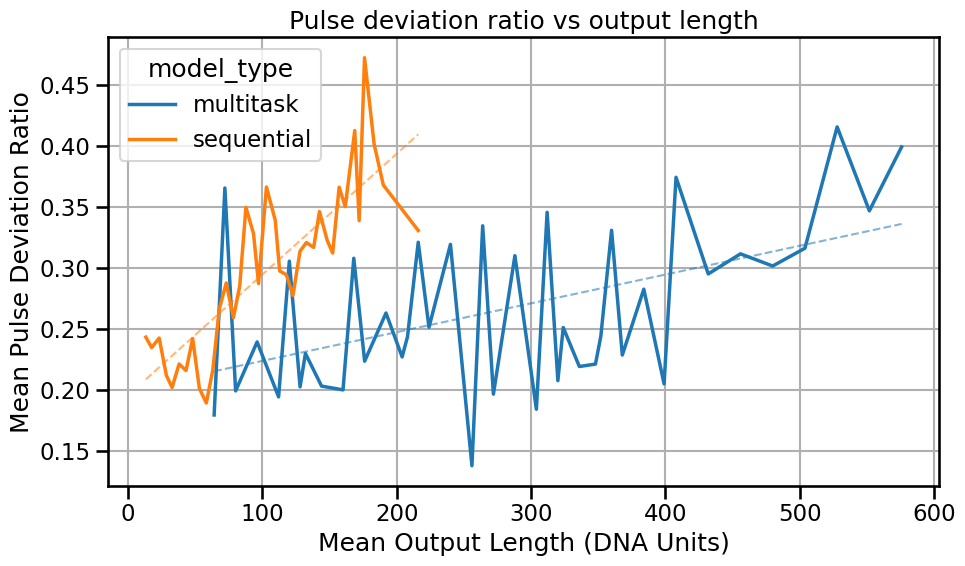

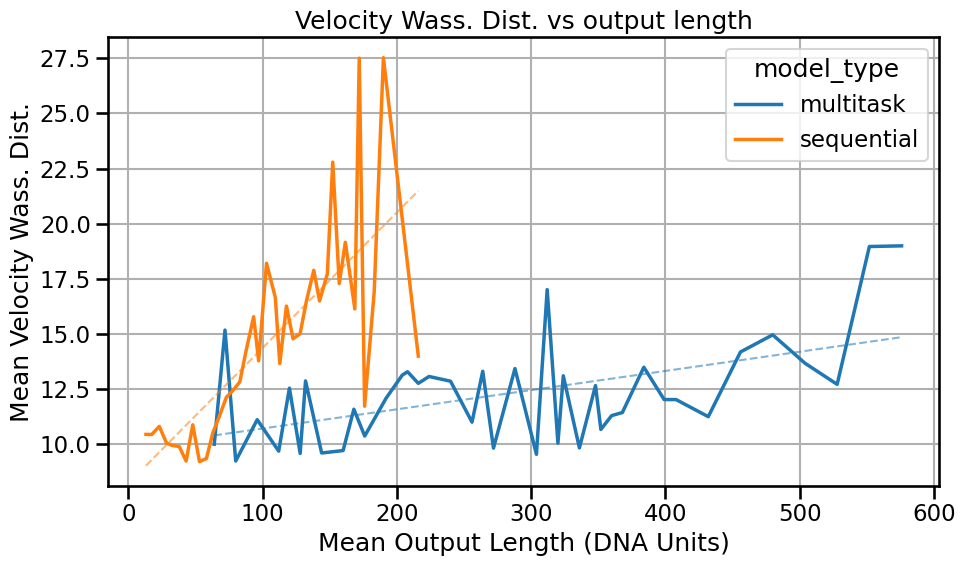

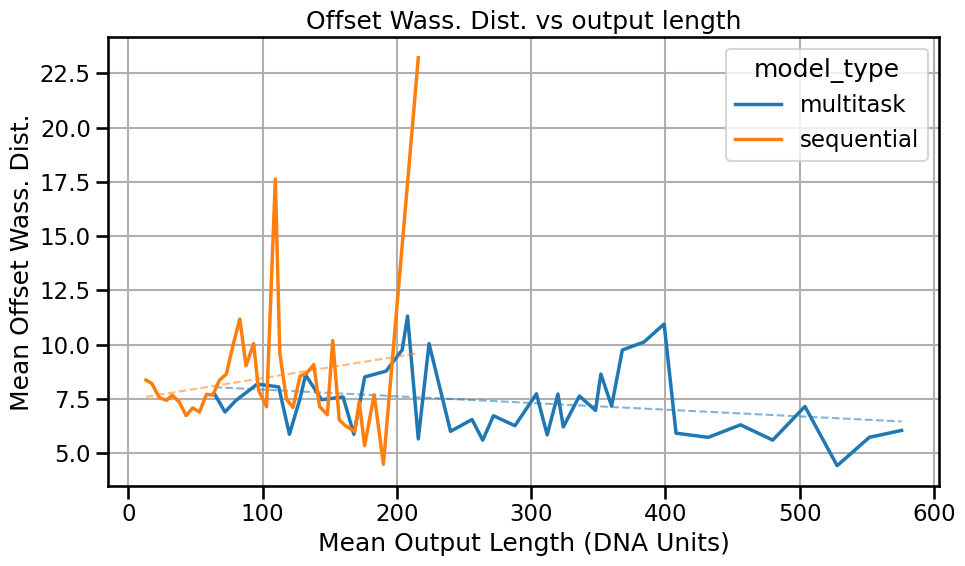

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 0) Build a per-sample table with the 3 raw metrics you want
# -----------------------------
def _to_basename(s):
    if pd.isna(s):
        return s
    s = str(s)
    return s.replace("\\", "/").split("/")[-1]

# eval: unit_count + model_type keyed by dna
eval_base = eval_data[["dna", "model_type", "unit_count"]].copy()
eval_base["dna_key"] = eval_base["dna"].map(_to_basename)
eval_base["unit_count"] = pd.to_numeric(eval_base["unit_count"], errors="coerce")
eval_base = eval_base[["dna_key", "model_type", "unit_count"]].copy()

# dist: keep vel and off wasserstein separately
dist_comp = dist_df[["dna_file", "vel_wasserstein", "off_wasserstein"]].copy()
dist_comp["dna_key"] = dist_comp["dna_file"].map(_to_basename)
dist_comp["vel_wasserstein"] = pd.to_numeric(dist_comp["vel_wasserstein"], errors="coerce")
dist_comp["off_wasserstein"] = pd.to_numeric(dist_comp["off_wasserstein"], errors="coerce")
dist_comp = dist_comp[["dna_key", "vel_wasserstein", "off_wasserstein"]].copy()

# pulse: deviation_ratio (RAW) keyed by dna_file
pulse_comp = pulse_dev_df[["dna_file", "deviation_ratio"]].copy()
pulse_comp["dna_key"] = pulse_comp["dna_file"].map(_to_basename)
pulse_comp["deviation_ratio"] = pd.to_numeric(pulse_comp["deviation_ratio"], errors="coerce")
pulse_comp = pulse_comp[["dna_key", "deviation_ratio"]].copy()

# merge the three pieces (inner keeps only samples present in all 3)
m = (
    eval_base
    .merge(dist_comp, on="dna_key", how="inner")
    .merge(pulse_comp, on="dna_key", how="inner")
)

m = m.replace([np.inf, -np.inf], np.nan)
m = m.dropna(subset=["unit_count", "deviation_ratio", "vel_wasserstein", "off_wasserstein"]).copy()

print("Merged rows:", len(m))

# -----------------------------
# 1) Bin by unit_count (same pattern you used)
# -----------------------------
bin_width = 5  # adjust
u_min = int(np.floor(m["unit_count"].min()))
u_max = int(np.ceil(m["unit_count"].max()))
bins = np.arange(u_min, u_max + bin_width, bin_width)

m["length_bin"] = pd.cut(m["unit_count"], bins=bins, include_lowest=True)

# -----------------------------
# 2) Aggregate within bins by model_type
# -----------------------------
summary = (
    m.groupby(["model_type", "length_bin"], observed=True)
     .agg(
         n=("unit_count", "size"),
         mean_length=("unit_count", "mean"),
         mean_dev_ratio=("deviation_ratio", "mean"),
         mean_vel_wass=("vel_wasserstein", "mean"),
         mean_off_wass=("off_wasserstein", "mean"),
     )
     .reset_index()
)

min_n = 3
summary = summary[summary["n"] >= min_n].copy()

# -----------------------------
# 3) Plot helper (one chart per metric)
# -----------------------------

MODEL_COLORS = {
    "multitask": "tab:blue",
    "sequential": "tab:orange",
}

def plot_metric(y_col, y_label, title, fit="linear"):
    plt.figure(figsize=(10, 6))

    for mt in sorted(summary["model_type"].unique()):
        d = summary[summary["model_type"] == mt].sort_values("mean_length")
        x = d["mean_length"].to_numpy(dtype=float)
        y = d[y_col].to_numpy(dtype=float)

        color = MODEL_COLORS.get(mt, "gray")

        # main series
        plt.plot(
            x, y,
            color=color,
            linewidth=2.5,
            label=mt
        )

        # trend line
        if fit == "linear" and len(x) >= 2:
            a, b = np.polyfit(x, y, 1)
            xfit = np.linspace(x.min(), x.max(), 100)
            yfit = a * xfit + b

            plt.plot(
                xfit, yfit,
                color=color,
                linestyle="--",
                linewidth=1.5,
                alpha=0.55
            )

        elif fit == "quadratic" and len(x) >= 3:
            a, b, c = np.polyfit(x, y, 2)
            xfit = np.linspace(x.min(), x.max(), 100)
            yfit = a * xfit**2 + b * xfit + c

            plt.plot(
                xfit, yfit,
                color=color,
                linestyle="--",
                linewidth=1.5,
                alpha=0.55
            )

    plt.xlabel("Mean Output Length (DNA Units)")
    plt.ylabel(y_label)
    plt.title(f"{title}")
    plt.legend(title="model_type")
    plt.grid()
    plt.tight_layout()
    plt.show()

plot_metric("mean_dev_ratio", "Mean Pulse Deviation Ratio",
            "Pulse deviation ratio vs output length", fit="linear")

plot_metric("mean_vel_wass", "Mean Velocity Wass. Dist.",
            "Velocity Wass. Dist. vs output length", fit="linear")

plot_metric("mean_off_wass", "Mean Offset Wass. Dist.",
            "Offset Wass. Dist. vs output length", fit="linear")

In [59]:
eval_data[eval_data['model_type']=='sequential'].sort_values(by='unit_count', ascending=False)

,input_dna,input_midi,variation,model,model_type,pretrain_type,temperature,top_p,max_tokens,eval_type,unit_count,dna,midi
19952,EvalData/OriginalInputs/dna/fbo_1_126.json,EvalData/OriginalInputs/midi/fbo_1_126.mid,0,sequential_large_finetune,sequential,finetune,1.0,0.90,400,sequence_length,216,EvalData/sequential_large_finetune_maxtok400/d...,EvalData/sequential_large_finetune_maxtok400/m...
12686,EvalData/OriginalInputs/dna/fbo_3_66.json,EvalData/OriginalInputs/midi/fbo_3_66.mid,2,sequential_large,sequential,pretrain,0.8,0.80,200,creativeness,190,EvalData/sequential_large_temp0.8_top_p0.8/dna...,EvalData/sequential_large_temp0.8_top_p0.8/mid...
16802,EvalData/OriginalInputs/dna/wb_6510.json,EvalData/OriginalInputs/midi/wb_6510.mid,0,sequential_large_finetune,sequential,finetune,0.8,0.90,200,creativeness,184,EvalData/sequential_large_finetune_temp0.8_top...,EvalData/sequential_large_finetune_temp0.8_top...
13171,EvalData/OriginalInputs/dna/fbo_7_60.json,EvalData/OriginalInputs/midi/fbo_7_60.mid,1,sequential_large,sequential,pretrain,0.8,0.90,200,creativeness,184,EvalData/sequential_large_temp0.8_top_p0.9/dna...,EvalData/sequential_large_temp0.8_top_p0.9/mid...
13137,EvalData/OriginalInputs/dna/fbo_3_66.json,EvalData/OriginalInputs/midi/fbo_3_66.mid,1,sequential_large,sequential,pretrain,0.8,0.90,200,creativeness,184,EvalData/sequential_large_temp0.8_top_p0.9/dna...,EvalData/sequential_large_temp0.8_top_p0.9/mid...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15942,EvalData/OriginalInputs/dna/wb_1278.json,EvalData/OriginalInputs/midi/wb_1278.mid,2,sequential_large,sequential,pretrain,1.2,0.95,200,creativeness,10,EvalData/sequential_large_temp1.2_top_p0.95/dn...,EvalData/sequential_large_temp1.2_top_p0.95/mi...
15956,EvalData/OriginalInputs/dna/wb_2335.json,EvalData/OriginalInputs/midi/wb_2335.mid,1,sequential_large,sequential,pretrain,1.2,0.95,200,creativeness,10,EvalData/sequential_large_temp1.2_top_p0.95/dn...,EvalData/sequential_large_temp1.2_top_p0.95/mi...
19408,EvalData/OriginalInputs/dna/hs_3217.json,EvalData/OriginalInputs/midi/hs_3217.mid,0,sequential_large_finetune,sequential,finetune,1.0,0.90,100,sequence_length,10,EvalData/sequential_large_finetune_maxtok100/d...,EvalData/sequential_large_finetune_maxtok100/m...
17640,EvalData/OriginalInputs/dna/fbo_3_27.json,EvalData/OriginalInputs/midi/fbo_3_27.mid,2,sequential_large_finetune,sequential,finetune,1.0,0.90,200,creativeness,10,EvalData/sequential_large_finetune_temp1.0_top...,EvalData/sequential_large_finetune_temp1.0_top...


In [60]:
dist_df.columns

Index(['dna_file', 'input_dna_file', 'vel_kl_input_output',
       'vel_kl_output_input', 'vel_jensen_shannon', 'vel_hellinger',
       'vel_wasserstein', 'off_kl_input_output', 'off_kl_output_input',
       'off_jensen_shannon', 'off_hellinger', 'off_wasserstein'],
      dtype='object')

In [61]:
pulse_dev_df.columns

Index(['Unnamed: 0', 'dna_file', 'input_dna_file', 'sequence_length',
       'hamming_distance', 'shift', 'deviation_count', 'per_position',
       'deviation_ratio'],
      dtype='object')

In [62]:
df_events.columns

Index(['model_type', 'direction', 'dna_path', 'input_dna_path', 'unit_idx',
       'value_part_key', 'inst_part', 'microtiming', 'midi_velocity'],
      dtype='object')